In [2]:
import sys
print(sys.version)
import pandas as pd
print("pandas works!", pd.__version__)

3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]
pandas works! 2.3.3


In [3]:
import pandas as pd
print("pandas works!", pd.__version__)

pandas works! 2.3.3


In [4]:
import pandas as pd

train = pd.read_csv('C:/retailpulse/data/train.csv', nrows=100000)

print("Shape:", train.shape)
print("\nFirst 5 rows:")
print(train.head())
print("\nColumn types:")
print(train.dtypes)


Shape: (100000, 6)

First 5 rows:
   id        date  store_nbr  item_nbr  unit_sales  onpromotion
0   0  2013-01-01         25    103665         7.0          NaN
1   1  2013-01-01         25    105574         1.0          NaN
2   2  2013-01-01         25    105575         2.0          NaN
3   3  2013-01-01         25    108079         1.0          NaN
4   4  2013-01-01         25    108701         1.0          NaN

Column types:
id               int64
date            object
store_nbr        int64
item_nbr         int64
unit_sales     float64
onpromotion    float64
dtype: object


In [5]:
stores = pd.read_csv('C:/retailpulse/data/stores.csv')
items = pd.read_csv('C:/retailpulse/data/items.csv')
oil = pd.read_csv('C:/retailpulse/data/oil.csv')
holidays = pd.read_csv('C:/retailpulse/data/holidays_events.csv')
transactions = pd.read_csv('C:/retailpulse/data/transactions.csv')

print("=== STORES ===")
print(stores.head(3))
print("\n=== ITEMS ===")
print(items.head(3))
print("\n=== OIL ===")
print(oil.head(3))
print("\n=== HOLIDAYS ===")
print(holidays.head(3))
print("\n=== TRANSACTIONS ===")
print(transactions.head(3))

=== STORES ===
   store_nbr   city      state type  cluster
0          1  Quito  Pichincha    D       13
1          2  Quito  Pichincha    D       13
2          3  Quito  Pichincha    D        8

=== ITEMS ===
   item_nbr     family  class  perishable
0     96995  GROCERY I   1093           0
1     99197  GROCERY I   1067           0
2    103501   CLEANING   3008           0

=== OIL ===
         date  dcoilwtico
0  2013-01-01         NaN
1  2013-01-02       93.14
2  2013-01-03       92.97

=== HOLIDAYS ===
         date     type    locale locale_name                    description  \
0  2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1  2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2  2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   

   transferred  
0        False  
1        False  
2        False  

=== TRANSACTIONS ===
         date  store_nbr  transactions
0  2013-01-01         25           770
1 

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Load full train (will take 1-2 mins)
print("Loading full dataset...")
train = pd.read_csv('C:/retailpulse/data/train.csv', 
                    parse_dates=['date'],
                    dtype={'onpromotion': 'float32', 'unit_sales': 'float32'})

print("Shape:", train.shape)
print("Date range:", train['date'].min(), "to", train['date'].max())
print("Stores:", train['store_nbr'].nunique())
print("Items:", train['item_nbr'].nunique())
print("Missing values:\n", train.isnull().sum())

Loading full dataset...
Shape: (125497040, 6)
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Stores: 54
Items: 4036
Missing values:
 id                    0
date                  0
store_nbr             0
item_nbr              0
unit_sales            0
onpromotion    21657651
dtype: int64


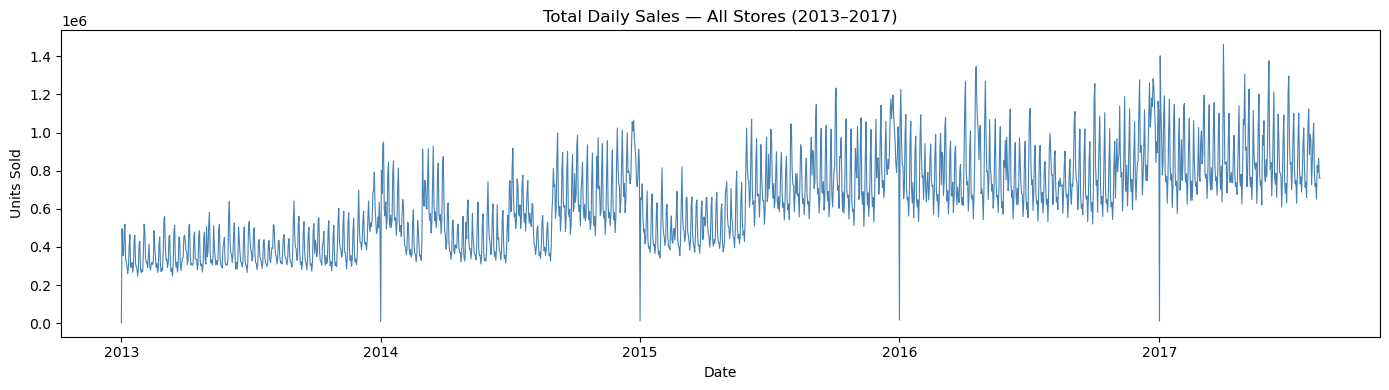

Chart saved!

Sales stats:
count    1.254970e+08
mean     8.554866e+00
std      2.306714e+01
min     -1.537200e+04
25%      2.000000e+00
50%      4.000000e+00
75%      9.000000e+00
max      8.944000e+04
Name: unit_sales, dtype: float64


In [7]:
import matplotlib.pyplot as plt

# Daily total sales over time
daily_sales = train.groupby('date')['unit_sales'].sum().reset_index()

plt.figure(figsize=(14, 4))
plt.plot(daily_sales['date'], daily_sales['unit_sales'], linewidth=0.8, color='steelblue')
plt.title('Total Daily Sales — All Stores (2013–2017)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.tight_layout()
plt.savefig('C:/retailpulse/reports/daily_sales_trend.png', dpi=150)
plt.show()
print("Chart saved!")

# Basic stats
print("\nSales stats:")
print(train['unit_sales'].describe())


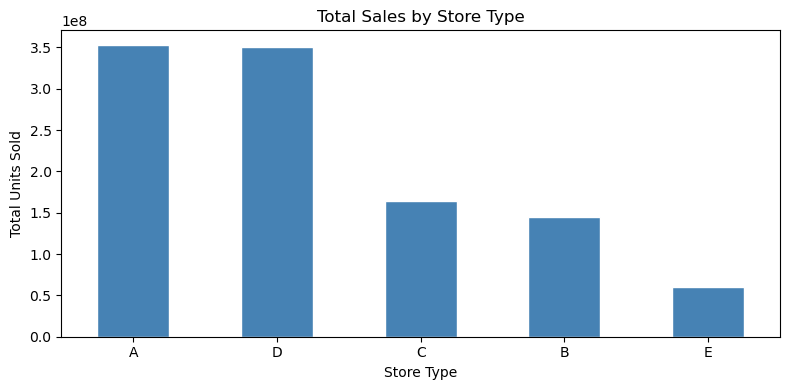

type
A    353043808.0
D    351063328.0
C    164434448.0
B    145248256.0
E     59820424.0
Name: unit_sales, dtype: float32


In [8]:

# Sales by store type
stores = pd.read_csv('C:/retailpulse/data/stores.csv')
train_stores = train.merge(stores, on='store_nbr')

store_type_sales = train_stores.groupby('type')['unit_sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
store_type_sales.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Total Sales by Store Type')
plt.xlabel('Store Type')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('C:/retailpulse/reports/sales_by_store_type.png', dpi=150)
plt.show()

print(store_type_sales)

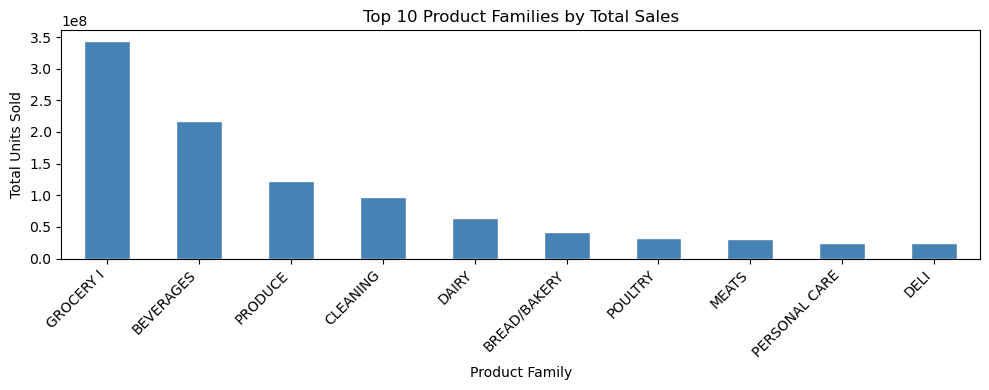

family
GROCERY I        343461728.0
BEVERAGES        216942240.0
PRODUCE          122704680.0
CLEANING          97518400.0
DAIRY             64487256.0
BREAD/BAKERY      42133944.0
POULTRY           31876004.0
MEATS             31086468.0
PERSONAL CARE     24580944.0
DELI              24110322.0
Name: unit_sales, dtype: float32


In [9]:
items = pd.read_csv('C:/retailpulse/data/items.csv')
train_items = train.merge(items, on='item_nbr')

family_sales = train_items.groupby('family')['unit_sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4))
family_sales.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 Product Families by Total Sales')
plt.xlabel('Product Family')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('C:/retailpulse/reports/sales_by_family.png', dpi=150)
plt.show()

print(family_sales)

In [10]:
# ABC-XYZ Classification
# ABC = sales volume (A=top 70%, B=next 20%, C=bottom 10%)
# XYZ = demand variability (X=stable, Y=moderate, Z=erratic)

item_stats = train.groupby('item_nbr').agg(
    total_sales=('unit_sales', 'sum'),
    std_sales=('unit_sales', 'std'),
    mean_sales=('unit_sales', 'mean')
).reset_index()

# ABC classification
item_stats = item_stats.sort_values('total_sales', ascending=False)
item_stats['cumulative_pct'] = item_stats['total_sales'].cumsum() / item_stats['total_sales'].sum() * 100
item_stats['ABC'] = 'C'
item_stats.loc[item_stats['cumulative_pct'] <= 70, 'ABC'] = 'A'
item_stats.loc[(item_stats['cumulative_pct'] > 70) & (item_stats['cumulative_pct'] <= 90), 'ABC'] = 'B'

# XYZ classification
item_stats['cv'] = item_stats['std_sales'] / item_stats['mean_sales']
item_stats['XYZ'] = 'Z'
item_stats.loc[item_stats['cv'] <= 0.5, 'XYZ'] = 'X'
item_stats.loc[(item_stats['cv'] > 0.5) & (item_stats['cv'] <= 1.0), 'XYZ'] = 'Y'

item_stats['ABC_XYZ'] = item_stats['ABC'] + item_stats['XYZ']

print(item_stats['ABC_XYZ'].value_counts())
print("\nSample:")
print(item_stats[['item_nbr', 'total_sales', 'ABC', 'XYZ', 'ABC_XYZ']].head(10))

ABC_XYZ
CY    993
CZ    817
AZ    769
BZ    597
BY    477
AY    342
CX     39
BX      2
Name: count, dtype: int64

Sample:
      item_nbr  total_sales ABC XYZ ABC_XYZ
2809   1503844    6264200.0   A   Y      AY
1451   1047679    5512875.0   A   Z      AZ
2739   1473474    4990322.5   A   Z      AZ
393     364606    4416426.0   A   Y      AY
1033    819932    4410943.0   A   Z      AZ
2601   1463992    4408545.0   A   Z      AZ
1004    807493    4321424.0   A   Z      AZ
240     265559    4112827.0   A   Z      AZ
574     502331    3703350.0   A   Y      AY
302     314384    3544341.0   A   Y      AY


In [11]:
# Save ABC-XYZ results
item_stats.to_csv('C:/retailpulse/data/abc_xyz_classification.csv', index=False)
print("ABC-XYZ saved!")

# Focus on A items only for forecasting (top 70% of sales value)
a_items = item_stats[item_stats['ABC'] == 'A']['item_nbr'].tolist()
print(f"Total A-class items to forecast: {len(a_items)}")

# Filter train to A items only
train_a = train[train['item_nbr'].isin(a_items)].copy()
print(f"Rows after filtering to A items: {len(train_a):,}")
print(f"Date range: {train_a['date'].min()} to {train_a['date'].max()}")



ABC-XYZ saved!
Total A-class items to forecast: 1111
Rows after filtering to A items: 57,573,693
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00


In [12]:
# Build forecasting dataset for one store-item combo first (to test)
# We'll use store 1, top selling item

top_item = item_stats[item_stats['ABC']=='A']['item_nbr'].iloc[0]
print(f"Testing with item: {top_item}")

# Filter to one store-item
ts = train_a[(train_a['item_nbr']==top_item) & 
             (train_a['store_nbr']==1)].copy()

ts = ts.sort_values('date')
ts['unit_sales'] = ts['unit_sales'].clip(lower=0)  # remove returns

# Add time features
ts['dayofweek'] = ts['date'].dt.dayofweek
ts['month'] = ts['date'].dt.month
ts['year'] = ts['date'].dt.year
ts['weekofyear'] = ts['date'].dt.isocalendar().week.astype(int)

# Add lag features
ts['lag_7'] = ts['unit_sales'].shift(7)
ts['lag_14'] = ts['unit_sales'].shift(14)
ts['lag_28'] = ts['unit_sales'].shift(28)
ts['rolling_mean_7'] = ts['unit_sales'].shift(1).rolling(7).mean()
ts['rolling_mean_28'] = ts['unit_sales'].shift(1).rolling(28).mean()

ts = ts.dropna()
print(f"Rows: {len(ts)}")
print(ts.head())

Testing with item: 1503844
Rows: 954
                id       date  store_nbr  item_nbr  unit_sales  onpromotion  \
26228703  26228703 2014-07-01          1   1503844  139.979996          0.0   
26298050  26298050 2014-07-02          1   1503844  122.551003          1.0   
26367142  26367142 2014-07-03          1   1503844  103.582001          0.0   
26434147  26434147 2014-07-04          1   1503844  142.990005          0.0   
26500742  26500742 2014-07-05          1   1503844  127.194000          0.0   

          dayofweek  month  year  weekofyear       lag_7      lag_14  \
26228703          1      7  2014          27  161.744995  176.744995   
26298050          2      7  2014          27  217.134094  193.073196   
26367142          3      7  2014          27  113.816002  102.357002   
26434147          4      7  2014          27  149.806000  159.347000   
26500742          5      7  2014          27  155.020004  183.378006   

              lag_28  rolling_mean_7  rolling_mean_28  

In [13]:
import subprocess
subprocess.run(['C:/Users/mavls/anaconda3/python.exe', '-m', 'pip', 'install', 'lightgbm'], check=True)
print("Done!")

Done!


In [14]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import numpy as np

# Features and target
features = ['dayofweek', 'month', 'year', 'weekofyear', 
            'lag_7', 'lag_14', 'lag_28', 
            'rolling_mean_7', 'rolling_mean_28', 'onpromotion']

ts['onpromotion'] = ts['onpromotion'].fillna(0)

# Train/test split — last 60 days as test
split_date = ts['date'].max() - pd.Timedelta(days=60)
train_ts = ts[ts['date'] <= split_date]
test_ts = ts[ts['date'] > split_date]

X_train = train_ts[features]
y_train = train_ts['unit_sales']
X_test = test_ts[features]
y_test = test_ts['unit_sales']

# Train LightGBM
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)
model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)
preds = np.clip(preds, 0, None)

mae = mean_absolute_error(y_test, preds)
print(f"MAE: {mae:.2f} units")
print(f"Mean actual sales: {y_test.mean():.2f} units")
print(f"Error rate: {mae/y_test.mean()*100:.1f}%")

MAE: 28.35 units
Mean actual sales: 147.25 units
Error rate: 19.3%


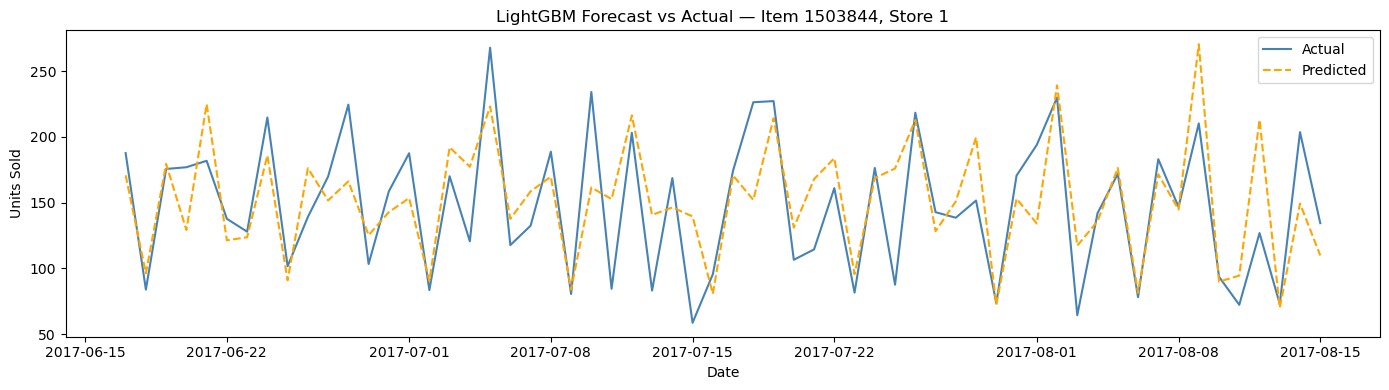

Chart saved!


In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(test_ts['date'].values, y_test.values, label='Actual', color='steelblue', linewidth=1.5)
plt.plot(test_ts['date'].values, preds, label='Predicted', color='orange', linewidth=1.5, linestyle='--')
plt.title(f'LightGBM Forecast vs Actual — Item {top_item}, Store 1')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.savefig('C:/retailpulse/reports/forecast_vs_actual.png', dpi=150)
plt.show()
print("Chart saved!")

In [16]:
# Load external data
oil = pd.read_csv('C:/retailpulse/data/oil.csv', parse_dates=['date'])
holidays = pd.read_csv('C:/retailpulse/data/holidays_events.csv', parse_dates=['date'])

# Fill missing oil prices with forward fill
oil = oil.set_index('date').resample('D').mean().ffill().reset_index()
oil.columns = ['date', 'oil_price']

# Simplify holidays — just flag national holidays
national_holidays = holidays[holidays['locale'] == 'National'][['date']].copy()
national_holidays['is_holiday'] = 1

# Rebuild ts with external features
ts2 = train_a[(train_a['item_nbr']==top_item) & 
              (train_a['store_nbr']==1)].copy()
ts2 = ts2.sort_values('date')
ts2['unit_sales'] = ts2['unit_sales'].clip(lower=0)

# Merge oil and holidays
ts2 = ts2.merge(oil, on='date', how='left')
ts2 = ts2.merge(national_holidays, on='date', how='left')
ts2['is_holiday'] = ts2['is_holiday'].fillna(0)
ts2['onpromotion'] = ts2['onpromotion'].fillna(0)
ts2['oil_price'] = ts2['oil_price'].ffill()

# Time features
ts2['dayofweek'] = ts2['date'].dt.dayofweek
ts2['month'] = ts2['date'].dt.month
ts2['year'] = ts2['date'].dt.year
ts2['weekofyear'] = ts2['date'].dt.isocalendar().week.astype(int)

# Lag features
ts2['lag_7'] = ts2['unit_sales'].shift(7)
ts2['lag_14'] = ts2['unit_sales'].shift(14)
ts2['lag_28'] = ts2['unit_sales'].shift(28)
ts2['rolling_mean_7'] = ts2['unit_sales'].shift(1).rolling(7).mean()
ts2['rolling_mean_28'] = ts2['unit_sales'].shift(1).rolling(28).mean()

ts2 = ts2.dropna()
print(f"Rows: {len(ts2)}")
print(f"Columns: {ts2.columns.tolist()}")

Rows: 991
Columns: ['id', 'date', 'store_nbr', 'item_nbr', 'unit_sales', 'onpromotion', 'oil_price', 'is_holiday', 'dayofweek', 'month', 'year', 'weekofyear', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_28']


In [17]:
# Updated features including oil and holidays
features2 = ['dayofweek', 'month', 'year', 'weekofyear', 
             'lag_7', 'lag_14', 'lag_28', 
             'rolling_mean_7', 'rolling_mean_28', 
             'onpromotion', 'oil_price', 'is_holiday']

# Train/test split
split_date = ts2['date'].max() - pd.Timedelta(days=60)
train_ts2 = ts2[ts2['date'] <= split_date]
test_ts2 = ts2[ts2['date'] > split_date]

X_train2 = train_ts2[features2]
y_train2 = train_ts2['unit_sales']
X_test2 = test_ts2[features2]
y_test2 = test_ts2['unit_sales']

# Retrain LightGBM
model2 = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)
model2.fit(X_train2, y_train2)

preds2 = model2.predict(X_test2)
preds2 = np.clip(preds2, 0, None)

mae2 = mean_absolute_error(y_test2, preds2)
print(f"Baseline MAE: 28.35 units (19.3%)")
print(f"Enhanced MAE: {mae2:.2f} units ({mae2/y_test2.mean()*100:.1f}%)")
print(f"Improvement: {28.35 - mae2:.2f} units")

# Feature importance
import pandas as pd
importance = pd.DataFrame({
    'feature': features2,
    'importance': model2.feature_importances_
}).sort_values('importance', ascending=False)
print("\nFeature Importance:")
print(importance)

Baseline MAE: 28.35 units (19.3%)
Enhanced MAE: 26.60 units (18.1%)
Improvement: 1.75 units

Feature Importance:
            feature  importance
5            lag_14        2578
4             lag_7        2298
6            lag_28        2200
7    rolling_mean_7        2057
10        oil_price        1850
8   rolling_mean_28        1638
3        weekofyear         992
0         dayofweek         574
1             month         356
11       is_holiday         191
2              year         178
9       onpromotion          88


In [18]:
# Inventory Optimization — EOQ, Safety Stock, Reorder Point

avg_daily_demand = y_test2.mean()
std_daily_demand = y_test2.std()
lead_time_days = 7        # assume 7 day supplier lead time
service_level_z = 1.65   # 95% service level

# Safety Stock = Z * std * sqrt(lead time)
safety_stock = service_level_z * std_daily_demand * np.sqrt(lead_time_days)

# Reorder Point = avg demand during lead time + safety stock
reorder_point = (avg_daily_demand * lead_time_days) + safety_stock

# EOQ = sqrt(2 * annual demand * ordering cost / holding cost)
annual_demand = avg_daily_demand * 365
ordering_cost = 50    # $50 per order
holding_cost = 2      # $2 per unit per year
eoq = np.sqrt((2 * annual_demand * ordering_cost) / holding_cost)

print(f"=== INVENTORY METRICS — Item {top_item}, Store 1 ===")
print(f"Avg daily demand:  {avg_daily_demand:.1f} units")
print(f"Std daily demand:  {std_daily_demand:.1f} units")
print(f"Safety stock:      {safety_stock:.0f} units")
print(f"Reorder point:     {reorder_point:.0f} units")
print(f"EOQ:               {eoq:.0f} units per order")
print(f"Orders per year:   {annual_demand/eoq:.0f}")

=== INVENTORY METRICS — Item 1503844, Store 1 ===
Avg daily demand:  147.3 units
Std daily demand:  52.5 units
Safety stock:      229 units
Reorder point:     1260 units
EOQ:               1639 units per order
Orders per year:   33


In [19]:
# Save full results summary
summary = {
    'item_nbr': top_item,
    'store_nbr': 1,
    'abc_class': 'A',
    'xyz_class': item_stats[item_stats['item_nbr']==top_item]['XYZ'].values[0],
    'baseline_mae_pct': 19.3,
    'enhanced_mae_pct': round(mae2/y_test2.mean()*100, 1),
    'avg_daily_demand': round(avg_daily_demand, 1),
    'safety_stock': round(safety_stock),
    'reorder_point': round(reorder_point),
    'eoq': round(eoq),
    'orders_per_year': round(annual_demand/eoq)
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv('C:/retailpulse/reports/inventory_summary.csv', index=False)

print("=== PROJECT SUMMARY ===")
for k, v in summary.items():
    print(f"{k}: {v}")
print("\nAll outputs saved to C:/retailpulse/reports/")

=== PROJECT SUMMARY ===
item_nbr: 1503844
store_nbr: 1
abc_class: A
xyz_class: Y
baseline_mae_pct: 19.3
enhanced_mae_pct: 18.100000381469727
avg_daily_demand: 147.3000030517578
safety_stock: 229
reorder_point: 1260
eoq: 1639
orders_per_year: 33

All outputs saved to C:/retailpulse/reports/


In [21]:
dashboard_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

st.set_page_config(page_title="RetailPulse", layout="wide")

st.title("RetailPulse — Demand Forecasting & Inventory Dashboard")
st.caption("Supply Chain Analytics | Corporación Favorita Dataset")

# Load data
@st.cache_data
def load_data():
    abc_xyz = pd.read_csv("C:/retailpulse/data/abc_xyz_classification.csv")
    stores = pd.read_csv("C:/retailpulse/data/stores.csv")
    items = pd.read_csv("C:/retailpulse/data/items.csv")
    train = pd.read_csv("C:/retailpulse/data/train.csv", 
                        parse_dates=["date"],
                        dtype={"onpromotion": "float32", "unit_sales": "float32"},
                        nrows=500000)
    return abc_xyz, stores, items, train

with st.spinner("Loading data..."):
    abc_xyz, stores, items, train = load_data()

# Sidebar filters
st.sidebar.header("Filters")
abc_filter = st.sidebar.multiselect("ABC Class", ["A", "B", "C"], default=["A"])
xyz_filter = st.sidebar.multiselect("XYZ Class", ["X", "Y", "Z"], default=["X", "Y", "Z"])

filtered = abc_xyz[
    abc_xyz["ABC"].isin(abc_filter) & 
    abc_xyz["XYZ"].isin(xyz_filter)
]

# KPI row
col1, col2, col3, col4 = st.columns(4)
col1.metric("Total Items", f"{len(abc_xyz):,}")
col2.metric("Filtered Items", f"{len(filtered):,}")
col3.metric("Avg Daily Demand", f"{abc_xyz['mean_sales'].mean():.1f} units")
col4.metric("A-Class Items", f"{len(abc_xyz[abc_xyz['ABC']=='A']):,}")

st.divider()

# Row 1 — ABC-XYZ heatmap + distribution
col1, col2 = st.columns(2)

with col1:
    st.subheader("ABC-XYZ Classification Matrix")
    matrix = abc_xyz.groupby(["ABC", "XYZ"]).size().reset_index(name="count")
    pivot = matrix.pivot(index="ABC", columns="XYZ", values="count").fillna(0)
    fig = px.imshow(pivot, text_auto=True, color_continuous_scale="Blues",
                    labels=dict(x="XYZ Class", y="ABC Class", color="Items"))
    fig.update_layout(height=300, margin=dict(t=20, b=20))
    st.plotly_chart(fig, use_container_width=True)

with col2:
    st.subheader("Sales Distribution by ABC Class")
    fig2 = px.box(abc_xyz, x="ABC", y="total_sales", color="ABC",
                  color_discrete_map={"A": "#1D9E75", "B": "#378ADD", "C": "#D85A30"})
    fig2.update_layout(height=300, margin=dict(t=20, b=20), showlegend=False)
    fig2.update_yaxes(title="Total Sales")
    st.plotly_chart(fig2, use_container_width=True)

st.divider()

# Row 2 — Daily sales trend
st.subheader("Daily Sales Trend")
daily = train.groupby("date")["unit_sales"].sum().reset_index()
fig3 = px.line(daily, x="date", y="unit_sales", 
               color_discrete_sequence=["#1D9E75"])
fig3.update_layout(height=300, margin=dict(t=20, b=20))
fig3.update_yaxes(title="Units Sold")
st.plotly_chart(fig3, use_container_width=True)

st.divider()

# Row 3 — Inventory calculator
st.subheader("Inventory Calculator")
col1, col2, col3 = st.columns(3)

with col1:
    avg_demand = st.number_input("Avg daily demand (units)", value=147.0, step=1.0)
    std_demand = st.number_input("Std dev of demand", value=52.0, step=1.0)

with col2:
    lead_time = st.number_input("Lead time (days)", value=7, step=1)
    service_level = st.selectbox("Service level", ["90% (z=1.28)", "95% (z=1.65)", "99% (z=2.33)"])
    z = float(service_level.split("z=")[1].replace(")", ""))

with col3:
    ordering_cost = st.number_input("Ordering cost ($)", value=50.0, step=5.0)
    holding_cost = st.number_input("Holding cost ($/unit/year)", value=2.0, step=0.5)

safety_stock = z * std_demand * np.sqrt(lead_time)
reorder_point = (avg_demand * lead_time) + safety_stock
annual_demand = avg_demand * 365
eoq = np.sqrt((2 * annual_demand * ordering_cost) / holding_cost)

r1, r2, r3, r4 = st.columns(4)
r1.metric("Safety Stock", f"{safety_stock:.0f}

_IncompleteInputError: incomplete input (2041218911.py, line 1)

In [22]:
code = [
    "import streamlit as st\n",
    "import pandas as pd\n",
    "import numpy as np\n",
    "import plotly.express as px\n",
    "import plotly.graph_objects as go\n",
    "\n",
    "st.set_page_config(page_title='RetailPulse', layout='wide')\n",
    "st.title('RetailPulse — Demand Forecasting & Inventory Dashboard')\n",
    "st.caption('Supply Chain Analytics | Corporación Favorita Dataset')\n",
    "\n",
    "@st.cache_data\n",
    "def load_data():\n",
    "    abc_xyz = pd.read_csv('C:/retailpulse/data/abc_xyz_classification.csv')\n",
    "    stores = pd.read_csv('C:/retailpulse/data/stores.csv')\n",
    "    items = pd.read_csv('C:/retailpulse/data/items.csv')\n",
    "    train = pd.read_csv('C:/retailpulse/data/train.csv', parse_dates=['date'], dtype={'onpromotion':'float32','unit_sales':'float32'}, nrows=500000)\n",
    "    return abc_xyz, stores, items, train\n",
    "\n",
    "with st.spinner('Loading data...'):\n",
    "    abc_xyz, stores, items, train = load_data()\n",
    "\n",
    "st.sidebar.header('Filters')\n",
    "abc_filter = st.sidebar.multiselect('ABC Class', ['A','B','C'], default=['A'])\n",
    "xyz_filter = st.sidebar.multiselect('XYZ Class', ['X','Y','Z'], default=['X','Y','Z'])\n",
    "filtered = abc_xyz[abc_xyz['ABC'].isin(abc_filter) & abc_xyz['XYZ'].isin(xyz_filter)]\n",
    "\n",
    "col1,col2,col3,col4 = st.columns(4)\n",
    "col1.metric('Total Items', f\"{len(abc_xyz):,}\")\n",
    "col2.metric('Filtered Items', f\"{len(filtered):,}\")\n",
    "col3.metric('Avg Daily Demand', f\"{abc_xyz['mean_sales'].mean():.1f} units\")\n",
    "col4.metric('A-Class Items', f\"{len(abc_xyz[abc_xyz['ABC']=='A']):,}\")\n",
    "\n",
    "st.divider()\n",
    "col1,col2 = st.columns(2)\n",
    "\n",
    "with col1:\n",
    "    st.subheader('ABC-XYZ Classification Matrix')\n",
    "    matrix = abc_xyz.groupby(['ABC','XYZ']).size().reset_index(name='count')\n",
    "    pivot = matrix.pivot(index='ABC', columns='XYZ', values='count').fillna(0)\n",
    "    fig = px.imshow(pivot, text_auto=True, color_continuous_scale='Blues')\n",
    "    fig.update_layout(height=300, margin=dict(t=20,b=20))\n",
    "    st.plotly_chart(fig, use_container_width=True)\n",
    "\n",
    "with col2:\n",
    "    st.subheader('Sales Distribution by ABC Class')\n",
    "    fig2 = px.box(abc_xyz, x='ABC', y='total_sales', color='ABC',\n",
    "                  color_discrete_map={'A':'#1D9E75','B':'#378ADD','C':'#D85A30'})\n",
    "    fig2.update_layout(height=300, margin=dict(t=20,b=20), showlegend=False)\n",
    "    st.plotly_chart(fig2, use_container_width=True)\n",
    "\n",
    "st.divider()\n",
    "st.subheader('Daily Sales Trend')\n",
    "daily = train.groupby('date')['unit_sales'].sum().reset_index()\n",
    "fig3 = px.line(daily, x='date', y='unit_sales', color_discrete_sequence=['#1D9E75'])\n",
    "fig3.update_layout(height=300, margin=dict(t=20,b=20))\n",
    "st.plotly_chart(fig3, use_container_width=True)\n",
    "\n",
    "st.divider()\n",
    "st.subheader('Inventory Calculator')\n",
    "col1,col2,col3 = st.columns(3)\n",
    "with col1:\n",
    "    avg_demand = st.number_input('Avg daily demand (units)', value=147.0, step=1.0)\n",
    "    std_demand = st.number_input('Std dev of demand', value=52.0, step=1.0)\n",
    "with col2:\n",
    "    lead_time = st.number_input('Lead time (days)', value=7, step=1)\n",
    "    service_level = st.selectbox('Service level', ['90% (z=1.28)','95% (z=1.65)','99% (z=2.33)'])\n",
    "    z = float(service_level.split('z=')[1].replace(')',''))\n",
    "with col3:\n",
    "    ordering_cost = st.number_input('Ordering cost ($)', value=50.0, step=5.0)\n",
    "    holding_cost = st.number_input('Holding cost ($/unit/year)', value=2.0, step=0.5)\n",
    "\n",
    "safety_stock = z * std_demand * np.sqrt(lead_time)\n",
    "reorder_point = (avg_demand * lead_time) + safety_stock\n",
    "annual_demand = avg_demand * 365\n",
    "eoq = np.sqrt((2 * annual_demand * ordering_cost) / holding_cost)\n",
    "\n",
    "r1,r2,r3,r4 = st.columns(4)\n",
    "r1.metric('Safety Stock', f'{safety_stock:.0f} units')\n",
    "r2.metric('Reorder Point', f'{reorder_point:.0f} units')\n",
    "r3.metric('EOQ', f'{eoq:.0f} units')\n",
    "r4.metric('Orders/Year', f'{annual_demand/eoq:.0f}')\n",
    "\n",
    "st.divider()\n",
    "st.subheader('Top A-Class Items')\n",
    "top_items = abc_xyz[abc_xyz['ABC']=='A'].merge(items, on='item_nbr', how='left')\n",
    "top_items = top_items.sort_values('total_sales', ascending=False).head(20)\n",
    "top_items['total_sales'] = top_items['total_sales'].round(0).astype(int)\n",
    "top_items['mean_sales'] = top_items['mean_sales'].round(2)\n",
    "st.dataframe(top_items[['item_nbr','family','ABC','XYZ','ABC_XYZ','total_sales','mean_sales']], use_container_width=True, hide_index=True)\n",
]

with open("C:/retailpulse/dashboard/app.py", "w") as f:
    f.writelines(code)

print("Dashboard saved!")

Dashboard saved!


In [23]:
with open("C:/retailpulse/dashboard/app.py", "w", encoding="utf-8") as f:
    f.writelines(code)

print("Fixed!")

Fixed!


In [24]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

# Load data
print("Loading data...")
train = pd.read_csv('C:/retailpulse/data/train.csv', 
                    parse_dates=['date'],
                    dtype={'onpromotion':'float32','unit_sales':'float32'})
oil = pd.read_csv('C:/retailpulse/data/oil.csv', parse_dates=['date'])
holidays = pd.read_csv('C:/retailpulse/data/holidays_events.csv', parse_dates=['date'])
abc_xyz = pd.read_csv('C:/retailpulse/data/abc_xyz_classification.csv')

# Prep external data
oil = oil.set_index('date').resample('D').mean().ffill().reset_index()
oil.columns = ['date','oil_price']
national_holidays = holidays[holidays['locale']=='National'][['date']].copy()
national_holidays['is_holiday'] = 1

# Get A-class items
a_items = abc_xyz[abc_xyz['ABC']=='A']['item_nbr'].tolist()
print(f"Forecasting {len(a_items)} A-class items...")

# Filter train to A items
train_a = train[train['item_nbr'].isin(a_items)].copy()
train_a['unit_sales'] = train_a['unit_sales'].clip(lower=0)
train_a = train_a.merge(oil, on='date', how='left')
train_a = train_a.merge(national_holidays, on='date', how='left')
train_a['is_holiday'] = train_a['is_holiday'].fillna(0)
train_a['onpromotion'] = train_a['onpromotion'].fillna(0)
train_a['oil_price'] = train_a['oil_price'].ffill()

# Time features
train_a['dayofweek'] = train_a['date'].dt.dayofweek
train_a['month'] = train_a['date'].dt.month
train_a['year'] = train_a['date'].dt.year
train_a['weekofyear'] = train_a['date'].dt.isocalendar().week.astype(int)

print("Features added! Ready to train.")
print(f"Total rows: {len(train_a):,}")

Loading data...
Forecasting 1111 A-class items...
Features added! Ready to train.
Total rows: 57,736,869


In [25]:
features = ['dayofweek','month','year','weekofyear',
            'lag_7','lag_14','lag_28',
            'rolling_mean_7','rolling_mean_28',
            'onpromotion','oil_price','is_holiday']

results = []
errors = []

# Get unique store-item combos for A items (limit to 1 store per item for speed)
combos = train_a.groupby(['item_nbr','store_nbr']).size().reset_index()
combos = combos[combos['store_nbr']==1]  # store 1 only for now
print(f"Training {len(combos)} models...")

for i, row in combos.iterrows():
    item = row['item_nbr']
    store = row['store_nbr']
    
    try:
        ts = train_a[(train_a['item_nbr']==item) & 
                     (train_a['store_nbr']==store)].copy().sort_values('date')
        
        # Lag features
        ts['lag_7'] = ts['unit_sales'].shift(7)
        ts['lag_14'] = ts['unit_sales'].shift(14)
        ts['lag_28'] = ts['unit_sales'].shift(28)
        ts['rolling_mean_7'] = ts['unit_sales'].shift(1).rolling(7).mean()
        ts['rolling_mean_28'] = ts['unit_sales'].shift(1).rolling(28).mean()
        ts = ts.dropna()
        
        if len(ts) < 100:
            continue
            
        split_date = ts['date'].max() - pd.Timedelta(days=60)
        tr = ts[ts['date'] <= split_date]
        te = ts[ts['date'] > split_date]
        
        if len(te) < 10:
            continue
        
        model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05,
                                   num_leaves=31, random_state=42, verbosity=-1)
        model.fit(tr[features], tr['unit_sales'])
        preds = np.clip(model.predict(te[features]), 0, None)
        
        mae = mean_absolute_error(te['unit_sales'], preds)
        mean_sales = te['unit_sales'].mean()
        
        # Inventory metrics
        std_sales = te['unit_sales'].std()
        safety_stock = 1.65 * std_sales * np.sqrt(7)
        reorder_point = (mean_sales * 7) + safety_stock
        annual_demand = mean_sales * 365
        eoq = np.sqrt((2 * annual_demand * 50) / 2)
        
        results.append({
            'item_nbr': item,
            'store_nbr': store,
            'mae': round(mae, 2),
            'mean_sales': round(mean_sales, 2),
            'mae_pct': round(mae/mean_sales*100, 1) if mean_sales > 0 else None,
            'safety_stock': round(safety_stock),
            'reorder_point': round(reorder_point),
            'eoq': round(eoq)
        })
        
        if len(results) % 100 == 0:
            print(f"  {len(results)} models trained...")
            
    except Exception as e:
        errors.append({'item_nbr': item, 'error': str(e)})

results_df = pd.DataFrame(results)
results_df.to_csv('C:/retailpulse/data/forecast_results.csv', index=False)
print(f"\nDone! {len(results)} models trained, {len(errors)} errors")
print(f"Avg MAE%: {results_df['mae_pct'].mean():.1f}%")
print(results_df.head())

Training 1052 models...
  100 models trained...
  200 models trained...
  300 models trained...
  400 models trained...
  500 models trained...
  600 models trained...
  700 models trained...
  800 models trained...
  900 models trained...
  1000 models trained...

Done! 1019 models trained, 0 errors
Avg MAE%: 59.2%
   item_nbr  store_nbr   mae  mean_sales    mae_pct  safety_stock  \
0    105574          1  2.14        5.68  37.599998            13   
1    105575          1  3.48       10.20  34.099998            24   
2    105857          1  2.80        5.26  53.299999            14   
3    106716          1  1.51        3.10  48.500000             7   
4    108786          1  1.43        2.64  54.200001             8   

   reorder_point  eoq  
0             53  322  
1             95  431  
2             50  310  
3             29  238  
4             26  219  


In [26]:
code = [
    "import streamlit as st\n",
    "import pandas as pd\n",
    "import numpy as np\n",
    "import plotly.express as px\n",
    "import plotly.graph_objects as go\n",
    "\n",
    "st.set_page_config(page_title='RetailPulse', layout='wide')\n",
    "st.title('RetailPulse — Demand Forecasting & Inventory Dashboard')\n",
    "st.caption('Supply Chain Analytics | Corporación Favorita Dataset')\n",
    "\n",
    "@st.cache_data\n",
    "def load_data():\n",
    "    abc_xyz = pd.read_csv('C:/retailpulse/data/abc_xyz_classification.csv')\n",
    "    items = pd.read_csv('C:/retailpulse/data/items.csv')\n",
    "    results = pd.read_csv('C:/retailpulse/data/forecast_results.csv')\n",
    "    train = pd.read_csv('C:/retailpulse/data/train.csv', parse_dates=['date'],\n",
    "                        dtype={'onpromotion':'float32','unit_sales':'float32'}, nrows=500000)\n",
    "    oil = pd.read_csv('C:/retailpulse/data/oil.csv', parse_dates=['date'])\n",
    "    return abc_xyz, items, results, train, oil\n",
    "\n",
    "with st.spinner('Loading data...'):\n",
    "    abc_xyz, items, results, train, oil = load_data()\n",
    "\n",
    "results_full = results.merge(abc_xyz[['item_nbr','ABC','XYZ','ABC_XYZ']], on='item_nbr', how='left')\n",
    "results_full = results_full.merge(items[['item_nbr','family']], on='item_nbr', how='left')\n",
    "\n",
    "st.sidebar.header('Filters')\n",
    "abc_filter = st.sidebar.multiselect('ABC Class', ['A','B','C'], default=['A'])\n",
    "xyz_filter = st.sidebar.multiselect('XYZ Class', ['X','Y','Z'], default=['X','Y','Z'])\n",
    "filtered = abc_xyz[abc_xyz['ABC'].isin(abc_filter) & abc_xyz['XYZ'].isin(xyz_filter)]\n",
    "\n",
    "col1,col2,col3,col4 = st.columns(4)\n",
    "col1.metric('Models Trained', f\"{len(results):,}\")\n",
    "col2.metric('Avg MAE%', f\"{results['mae_pct'].median():.1f}%\")\n",
    "col3.metric('Total A-Items', f\"{len(abc_xyz[abc_xyz['ABC']=='A']):,}\")\n",
    "col4.metric('Avg Daily Demand', f\"{results['mean_sales'].mean():.1f} units\")\n",
    "\n",
    "st.divider()\n",
    "\n",
    "col1,col2 = st.columns(2)\n",
    "with col1:\n",
    "    st.subheader('ABC-XYZ Classification Matrix')\n",
    "    matrix = abc_xyz.groupby(['ABC','XYZ']).size().reset_index(name='count')\n",
    "    pivot = matrix.pivot(index='ABC', columns='XYZ', values='count').fillna(0)\n",
    "    fig = px.imshow(pivot, text_auto=True, color_continuous_scale='Blues')\n",
    "    fig.update_layout(height=300, margin=dict(t=20,b=20))\n",
    "    st.plotly_chart(fig, use_container_width=True)\n",
    "\n",
    "with col2:\n",
    "    st.subheader('Forecast Error by Product Family')\n",
    "    fam_mae = results_full.groupby('family')['mae_pct'].median().sort_values().reset_index()\n",
    "    fig2 = px.bar(fam_mae, x='mae_pct', y='family', orientation='h',\n",
    "                  color='mae_pct', color_continuous_scale='RdYlGn_r')\n",
    "    fig2.update_layout(height=300, margin=dict(t=20,b=20))\n",
    "    st.plotly_chart(fig2, use_container_width=True)\n",
    "\n",
    "st.divider()\n",
    "\n",
    "col1,col2 = st.columns(2)\n",
    "with col1:\n",
    "    st.subheader('Daily Sales Trend')\n",
    "    daily = train.groupby('date')['unit_sales'].sum().reset_index()\n",
    "    fig3 = px.line(daily, x='date', y='unit_sales', color_discrete_sequence=['#1D9E75'])\n",
    "    fig3.update_layout(height=280, margin=dict(t=20,b=20))\n",
    "    st.plotly_chart(fig3, use_container_width=True)\n",
    "\n",
    "with col2:\n",
    "    st.subheader('Oil Price Trend')\n",
    "    fig4 = px.line(oil, x='date', y='dcoilwtico', color_discrete_sequence=['#D85A30'])\n",
    "    fig4.update_layout(height=280, margin=dict(t=20,b=20))\n",
    "    fig4.update_yaxes(title='USD per barrel')\n",
    "    st.plotly_chart(fig4, use_container_width=True)\n",
    "\n",
    "st.divider()\n",
    "\n",
    "col1,col2 = st.columns(2)\n",
    "with col1:\n",
    "    st.subheader('Safety Stock Distribution')\n",
    "    fig5 = px.histogram(results_full, x='safety_stock', color='XYZ',\n",
    "                        color_discrete_map={'X':'#1D9E75','Y':'#378ADD','Z':'#D85A30'},\n",
    "                        nbins=40)\n",
    "    fig5.update_layout(height=280, margin=dict(t=20,b=20))\n",
    "    st.plotly_chart(fig5, use_container_width=True)\n",
    "\n",
    "with col2:\n",
    "    st.subheader('EOQ vs Mean Daily Demand')\n",
    "    fig6 = px.scatter(results_full, x='mean_sales', y='eoq', color='XYZ',\n",
    "                      color_discrete_map={'X':'#1D9E75','Y':'#378ADD','Z':'#D85A30'},\n",
    "                      hover_data=['item_nbr','family'])\n",
    "    fig6.update_layout(height=280, margin=dict(t=20,b=20))\n",
    "    st.plotly_chart(fig6, use_container_width=True)\n",
    "\n",
    "st.divider()\n",
    "\n",
    "st.subheader('Inventory Calculator')\n",
    "col1,col2,col3 = st.columns(3)\n",
    "with col1:\n",
    "    avg_demand = st.number_input('Avg daily demand (units)', value=147.0, step=1.0)\n",
    "    std_demand = st.number_input('Std dev of demand', value=52.0, step=1.0)\n",
    "with col2:\n",
    "    lead_time = st.number_input('Lead time (days)', value=7, step=1)\n",
    "    service_level = st.selectbox('Service level', ['90% (z=1.28)','95% (z=1.65)','99% (z=2.33)'])\n",
    "    z = float(service_level.split('z=')[1].replace(')',''))\n",
    "with col3:\n",
    "    ordering_cost = st.number_input('Ordering cost ($)', value=50.0, step=5.0)\n",
    "    holding_cost = st.number_input('Holding cost ($/unit/year)', value=2.0, step=0.5)\n",
    "\n",
    "safety_stock = z * std_demand * np.sqrt(lead_time)\n",
    "reorder_point = (avg_demand * lead_time) + safety_stock\n",
    "annual_demand = avg_demand * 365\n",
    "eoq = np.sqrt((2 * annual_demand * ordering_cost) / holding_cost)\n",
    "\n",
    "r1,r2,r3,r4 = st.columns(4)\n",
    "r1.metric('Safety Stock', f'{safety_stock:.0f} units')\n",
    "r2.metric('Reorder Point', f'{reorder_point:.0f} units')\n",
    "r3.metric('EOQ', f'{eoq:.0f} units')\n",
    "r4.metric('Orders/Year', f'{annual_demand/eoq:.0f}')\n",
    "\n",
    "st.divider()\n",
    "st.subheader('Full Forecast Results Table')\n",
    "st.dataframe(\n",
    "    results_full[['item_nbr','family','ABC_XYZ','mean_sales','mae','mae_pct','safety_stock','reorder_point','eoq']]\n",
    "    .sort_values('mean_sales', ascending=False),\n",
    "    use_container_width=True, hide_index=True\n",
    ")\n",
]

with open("C:/retailpulse/dashboard/app.py", "w", encoding="utf-8") as f:
    f.writelines(code)

print("Dashboard updated!")

Dashboard updated!


In [27]:
import pandas as pd
import numpy as np

results = pd.read_csv('C:/retailpulse/data/forecast_results.csv')
abc_xyz = pd.read_csv('C:/retailpulse/data/abc_xyz_classification.csv')
items = pd.read_csv('C:/retailpulse/data/items.csv')

# Merge everything
df = results.merge(abc_xyz[['item_nbr','ABC','XYZ','ABC_XYZ']], on='item_nbr', how='left')
df = df.merge(items[['item_nbr','family','perishable']], on='item_nbr', how='left')

# Assume avg selling price by family (realistic estimates)
price_map = {
    'GROCERY I': 2.5, 'BEVERAGES': 3.0, 'PRODUCE': 1.8,
    'CLEANING': 4.0, 'DAIRY': 2.2, 'BREAD/BAKERY': 1.5,
    'POULTRY': 6.0, 'MEATS': 8.0, 'PERSONAL CARE': 5.0,
    'DELI': 4.5, 'FROZEN FOODS': 3.5, 'SEAFOOD': 9.0,
    'EGGS': 2.0, 'PREPARED FOODS': 5.5, 'SNACKS': 2.8
}
df['unit_price'] = df['family'].map(price_map).fillna(3.0)

# 1. P&L IMPACT — revenue at risk from forecast error
df['daily_revenue'] = df['mean_sales'] * df['unit_price']
df['revenue_at_risk'] = df['mae'] * df['unit_price']  # MAE units * price
df['annual_revenue'] = df['daily_revenue'] * 365
df['annual_revenue_at_risk'] = df['revenue_at_risk'] * 365

# 2. STOCKOUT COST — lost sales when demand > safety stock
# Stockout probability higher for Z items (erratic demand)
stockout_prob_map = {'X': 0.02, 'Y': 0.08, 'Z': 0.18}
df['stockout_prob'] = df['XYZ'].map(stockout_prob_map)
df['daily_stockout_cost'] = df['mean_sales'] * df['unit_price'] * df['stockout_prob']
df['annual_stockout_cost'] = df['daily_stockout_cost'] * 365

# Perishable items have higher stockout cost (waste + lost sale)
df.loc[df['perishable']==1, 'annual_stockout_cost'] *= 1.5

# 3. REORDER ALERTS — flag items below reorder point
# Simulate current inventory as random % of reorder point
np.random.seed(42)
df['current_stock'] = (df['reorder_point'] * np.random.uniform(0.4, 1.6, len(df))).round()
df['alert'] = df['current_stock'] <= df['reorder_point']
df['alert_urgency'] = 'OK'
df.loc[df['current_stock'] <= df['reorder_point'], 'alert_urgency'] = 'Reorder Now'
df.loc[df['current_stock'] <= df['reorder_point'] * 0.5, 'alert_urgency'] = 'Critical'

# Summary stats
print("=== P&L IMPACT SUMMARY ===")
print(f"Total annual revenue (A-items):     ${df['annual_revenue'].sum():,.0f}")
print(f"Total revenue at risk:              ${df['annual_revenue_at_risk'].sum():,.0f}")
print(f"Revenue at risk %:                  {df['annual_revenue_at_risk'].sum()/df['annual_revenue'].sum()*100:.1f}%")
print(f"\n=== STOCKOUT COST SUMMARY ===")
print(f"Total annual stockout cost:         ${df['annual_stockout_cost'].sum():,.0f}")
print(f"Perishable stockout cost:           ${df[df['perishable']==1]['annual_stockout_cost'].sum():,.0f}")
print(f"\n=== REORDER ALERTS ===")
print(df['alert_urgency'].value_counts())

df.to_csv('C:/retailpulse/data/business_outputs.csv', index=False)
print("\nSaved!")

=== P&L IMPACT SUMMARY ===
Total annual revenue (A-items):     $8,269,965
Total revenue at risk:              $4,521,065
Revenue at risk %:                  54.7%

=== STOCKOUT COST SUMMARY ===
Total annual stockout cost:         $1,471,983
Perishable stockout cost:           $696,155

=== REORDER ALERTS ===
alert_urgency
OK             497
Reorder Now    428
Critical        94
Name: count, dtype: int64

Saved!


In [28]:
code = [
    "import streamlit as st\n",
    "import pandas as pd\n",
    "import numpy as np\n",
    "import plotly.express as px\n",
    "import plotly.graph_objects as go\n",
    "\n",
    "st.set_page_config(page_title='RetailPulse', layout='wide')\n",
    "st.title('RetailPulse — Demand Forecasting & Inventory Dashboard')\n",
    "st.caption('Supply Chain Analytics | Corporación Favorita Dataset')\n",
    "\n",
    "@st.cache_data\n",
    "def load_data():\n",
    "    df = pd.read_csv('C:/retailpulse/data/business_outputs.csv')\n",
    "    train = pd.read_csv('C:/retailpulse/data/train.csv', parse_dates=['date'],\n",
    "                        dtype={'onpromotion':'float32','unit_sales':'float32'}, nrows=500000)\n",
    "    oil = pd.read_csv('C:/retailpulse/data/oil.csv', parse_dates=['date'])\n",
    "    return df, train, oil\n",
    "\n",
    "with st.spinner('Loading data...'):\n",
    "    df, train, oil = load_data()\n",
    "\n",
    "st.sidebar.header('Filters')\n",
    "abc_filter = st.sidebar.multiselect('ABC Class', ['A','B','C'], default=['A'])\n",
    "xyz_filter = st.sidebar.multiselect('XYZ Class', ['X','Y','Z'], default=['X','Y','Z'])\n",
    "urgency_filter = st.sidebar.multiselect('Alert Status', ['OK','Reorder Now','Critical'], default=['Reorder Now','Critical'])\n",
    "filtered = df[df['ABC'].isin(abc_filter) & df['XYZ'].isin(xyz_filter)]\n",
    "\n",
    "st.subheader('P&L Overview')\n",
    "k1,k2,k3,k4,k5 = st.columns(5)\n",
    "k1.metric('Annual Revenue', f\"${df['annual_revenue'].sum()/1e6:.2f}M\")\n",
    "k2.metric('Revenue at Risk', f\"${df['annual_revenue_at_risk'].sum()/1e6:.2f}M\",\n",
    "          delta=f\"{df['annual_revenue_at_risk'].sum()/df['annual_revenue'].sum()*100:.1f}% of revenue\",\n",
    "          delta_color='inverse')\n",
    "k3.metric('Stockout Cost', f\"${df['annual_stockout_cost'].sum()/1e6:.2f}M\", delta_color='inverse')\n",
    "k4.metric('Critical Alerts', f\"{len(df[df['alert_urgency']=='Critical'])}\", delta_color='inverse')\n",
    "k5.metric('Reorder Alerts', f\"{len(df[df['alert_urgency']=='Reorder Now'])}\")\n",
    "\n",
    "st.divider()\n",
    "\n",
    "col1,col2 = st.columns(2)\n",
    "with col1:\n",
    "    st.subheader('Revenue at Risk by Product Family')\n",
    "    fam = filtered.groupby('family').agg(\n",
    "        annual_revenue=('annual_revenue','sum'),\n",
    "        revenue_at_risk=('annual_revenue_at_risk','sum')\n",
    "    ).reset_index().sort_values('revenue_at_risk', ascending=False).head(10)\n",
    "    fig1 = go.Figure()\n",
    "    fig1.add_bar(x=fam['family'], y=fam['annual_revenue'], name='Total Revenue', marker_color='#1D9E75')\n",
    "    fig1.add_bar(x=fam['family'], y=fam['revenue_at_risk'], name='At Risk', marker_color='#D85A30')\n",
    "    fig1.update_layout(height=320, barmode='overlay', margin=dict(t=20,b=80),\n",
    "                       xaxis_tickangle=-35, legend=dict(orientation='h', y=1.1))\n",
    "    st.plotly_chart(fig1, use_container_width=True)\n",
    "\n",
    "with col2:\n",
    "    st.subheader('Stockout Cost by XYZ Class')\n",
    "    xyz_cost = filtered.groupby('XYZ')['annual_stockout_cost'].sum().reset_index()\n",
    "    fig2 = px.pie(xyz_cost, values='annual_stockout_cost', names='XYZ',\n",
    "                  color='XYZ', color_discrete_map={'X':'#1D9E75','Y':'#378ADD','Z':'#D85A30'})\n",
    "    fig2.update_layout(height=320, margin=dict(t=20,b=20))\n",
    "    st.plotly_chart(fig2, use_container_width=True)\n",
    "\n",
    "st.divider()\n",
    "\n",
    "col1,col2 = st.columns(2)\n",
    "with col1:\n",
    "    st.subheader('Daily Sales Trend')\n",
    "    daily = train.groupby('date')['unit_sales'].sum().reset_index()\n",
    "    fig3 = px.line(daily, x='date', y='unit_sales', color_discrete_sequence=['#1D9E75'])\n",
    "    fig3.update_layout(height=280, margin=dict(t=20,b=20))\n",
    "    st.plotly_chart(fig3, use_container_width=True)\n",
    "\n",
    "with col2:\n",
    "    st.subheader('Current Stock vs Reorder Point')\n",
    "    fig4 = px.scatter(filtered, x='reorder_point', y='current_stock',\n",
    "                      color='alert_urgency',\n",
    "                      color_discrete_map={'OK':'#1D9E75','Reorder Now':'#EF9F27','Critical':'#D85A30'},\n",
    "                      hover_data=['item_nbr','family','XYZ'])\n",
    "    fig4.add_shape(type='line', x0=0, y0=0,\n",
    "                   x1=filtered['reorder_point'].max(),\n",
    "                   y1=filtered['reorder_point'].max(),\n",
    "                   line=dict(color='gray', dash='dash'))\n",
    "    fig4.update_layout(height=280, margin=dict(t=20,b=20))\n",
    "    st.plotly_chart(fig4, use_container_width=True)\n",
    "\n",
    "st.divider()\n",
    "\n",
    "st.subheader('Reorder Alert Table')\n",
    "alert_df = df[df['alert_urgency'].isin(urgency_filter)].sort_values(\n",
    "    ['alert_urgency','annual_revenue_at_risk'], ascending=[True, False]\n",
    ")[['item_nbr','family','ABC_XYZ','alert_urgency','current_stock',\n",
    "   'reorder_point','eoq','annual_revenue','annual_revenue_at_risk','annual_stockout_cost']]\n",
    "alert_df['annual_revenue'] = alert_df['annual_revenue'].round(0).astype(int)\n",
    "alert_df['annual_revenue_at_risk'] = alert_df['annual_revenue_at_risk'].round(0).astype(int)\n",
    "alert_df['annual_stockout_cost'] = alert_df['annual_stockout_cost'].round(0).astype(int)\n",
    "\n",
    "def color_urgency(val):\n",
    "    if val == 'Critical': return 'background-color: #FCEBEB; color: #A32D2D'\n",
    "    if val == 'Reorder Now': return 'background-color: #FAEEDA; color: #854F0B'\n",
    "    return ''\n",
    "\n",
    "st.dataframe(\n",
    "    alert_df.style.applymap(color_urgency, subset=['alert_urgency']),\n",
    "    use_container_width=True, hide_index=True\n",
    ")\n",
    "\n",
    "st.divider()\n",
    "st.subheader('Inventory Calculator')\n",
    "col1,col2,col3 = st.columns(3)\n",
    "with col1:\n",
    "    avg_demand = st.number_input('Avg daily demand (units)', value=147.0, step=1.0)\n",
    "    std_demand = st.number_input('Std dev of demand', value=52.0, step=1.0)\n",
    "with col2:\n",
    "    lead_time = st.number_input('Lead time (days)', value=7, step=1)\n",
    "    service_level = st.selectbox('Service level', ['90% (z=1.28)','95% (z=1.65)','99% (z=2.33)'])\n",
    "    z = float(service_level.split('z=')[1].replace(')',''))\n",
    "with col3:\n",
    "    ordering_cost = st.number_input('Ordering cost ($)', value=50.0, step=5.0)\n",
    "    holding_cost = st.number_input('Holding cost ($/unit/year)', value=2.0, step=0.5)\n",
    "\n",
    "safety_stock = z * std_demand * np.sqrt(lead_time)\n",
    "reorder_point = (avg_demand * lead_time) + safety_stock\n",
    "annual_demand = avg_demand * 365\n",
    "eoq = np.sqrt((2 * annual_demand * ordering_cost) / holding_cost)\n",
    "\n",
    "r1,r2,r3,r4 = st.columns(4)\n",
    "r1.metric('Safety Stock', f'{safety_stock:.0f} units')\n",
    "r2.metric('Reorder Point', f'{reorder_point:.0f} units')\n",
    "r3.metric('EOQ', f'{eoq:.0f} units')\n",
    "r4.metric('Orders/Year', f'{annual_demand/eoq:.0f}')\n",
]

with open('C:/retailpulse/dashboard/app.py', 'w', encoding='utf-8') as f:
    f.writelines(code)

print("Dashboard updated!")

Dashboard updated!


In [30]:
import subprocess
subprocess.run(['C:/Users/mavls/anaconda3/python.exe', '-m', 'pip', 'install', 'duckdb'], check=True)
print("Done!")

Done!


In [32]:
import duckdb

con = duckdb.connect('C:/retailpulse/data/retailpulse.duckdb')

# Create all tables
print("Creating tables...")

con.execute("CREATE OR REPLACE TABLE raw_train AS SELECT * FROM read_csv_auto('C:/retailpulse/data/train.csv')")
print("  raw_train done")

con.execute("CREATE OR REPLACE TABLE raw_stores AS SELECT * FROM read_csv_auto('C:/retailpulse/data/stores.csv')")
print("  raw_stores done")

con.execute("CREATE OR REPLACE TABLE raw_items AS SELECT * FROM read_csv_auto('C:/retailpulse/data/items.csv')")
print("  raw_items done")

con.execute("CREATE OR REPLACE TABLE raw_oil AS SELECT * FROM read_csv_auto('C:/retailpulse/data/oil.csv')")
print("  raw_oil done")

con.execute("CREATE OR REPLACE TABLE raw_holidays AS SELECT * FROM read_csv_auto('C:/retailpulse/data/holidays_events.csv')")
print("  raw_holidays done")

con.execute("CREATE OR REPLACE TABLE abc_xyz AS SELECT * FROM read_csv_auto('C:/retailpulse/data/abc_xyz_classification.csv')")
print("  abc_xyz done")

con.execute("CREATE OR REPLACE TABLE business_outputs AS SELECT * FROM read_csv_auto('C:/retailpulse/data/business_outputs.csv')")
print("  business_outputs done")

print("\nAll tables ready!")
print(con.execute("SHOW TABLES").fetchdf())

Creating tables...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  raw_train done
  raw_stores done
  raw_items done
  raw_oil done
  raw_holidays done
  abc_xyz done
  business_outputs done

All tables ready!
               name
0           abc_xyz
1  business_outputs
2      raw_holidays
3         raw_items
4           raw_oil
5        raw_stores
6         raw_train


In [33]:
# Query 1 — Sales by store type
print("=== QUERY 1: Sales by Store Type ===")
q1 = con.execute("""
    SELECT 
        s.type AS store_type,
        COUNT(*) AS total_transactions,
        ROUND(SUM(t.unit_sales), 0) AS total_units_sold,
        ROUND(AVG(t.unit_sales), 2) AS avg_units_per_transaction
    FROM raw_train t
    JOIN raw_stores s ON t.store_nbr = s.store_nbr
    GROUP BY s.type
    ORDER BY total_units_sold DESC
""").fetchdf()
print(q1)

# Query 2 — Top 10 product families by revenue
print("\n=== QUERY 2: Top 10 Product Families ===")
q2 = con.execute("""
    SELECT 
        i.family,
        ROUND(SUM(t.unit_sales), 0) AS total_units,
        COUNT(DISTINCT t.store_nbr) AS stores_selling,
        COUNT(DISTINCT t.item_nbr) AS unique_items
    FROM raw_train t
    JOIN raw_items i ON t.item_nbr = i.item_nbr
    GROUP BY i.family
    ORDER BY total_units DESC
    LIMIT 10
""").fetchdf()
print(q2)

# Query 3 — Monthly sales trend
print("\n=== QUERY 3: Monthly Sales Trend ===")
q3 = con.execute("""
    SELECT 
        YEAR(CAST(date AS DATE)) AS year,
        MONTH(CAST(date AS DATE)) AS month,
        ROUND(SUM(unit_sales), 0) AS total_units,
        COUNT(DISTINCT store_nbr) AS active_stores
    FROM raw_train
    GROUP BY year, month
    ORDER BY year, month
""").fetchdf()
print(q3.tail(12))

=== QUERY 1: Sales by Store Type ===
  store_type  total_transactions  total_units_sold  avg_units_per_transaction
0          A            26830862       353043807.0                      13.16
1          D            46801370       351063325.0                       7.50
2          C            25908837       164434455.0                       6.35
3          B            17877340       145248257.0                       8.12
4          E             8078631        59820425.0                       7.40

=== QUERY 2: Top 10 Product Families ===
          family  total_units  stores_selling  unique_items
0      GROCERY I  343461728.0              54          1290
1      BEVERAGES  216942246.0              54           604
2        PRODUCE  122704679.0              54           306
3       CLEANING   97518398.0              54           446
4          DAIRY   64487256.0              54           242
5   BREAD/BAKERY   42133946.0              54           134
6        POULTRY   31876004.0    

In [34]:
import os
os.makedirs('C:/retailpulse/sql', exist_ok=True)

# SQL file 1
with open('C:/retailpulse/sql/01_create_tables.sql', 'w') as f:
    f.write("""-- RetailPulse: Create Tables
-- Run once to load all CSVs into DuckDB

CREATE OR REPLACE TABLE raw_train AS SELECT * FROM read_csv_auto('data/train.csv');
CREATE OR REPLACE TABLE raw_stores AS SELECT * FROM read_csv_auto('data/stores.csv');
CREATE OR REPLACE TABLE raw_items AS SELECT * FROM read_csv_auto('data/items.csv');
CREATE OR REPLACE TABLE raw_oil AS SELECT * FROM read_csv_auto('data/oil.csv');
CREATE OR REPLACE TABLE raw_holidays AS SELECT * FROM read_csv_auto('data/holidays_events.csv');
CREATE OR REPLACE TABLE abc_xyz AS SELECT * FROM read_csv_auto('data/abc_xyz_classification.csv');
CREATE OR REPLACE TABLE business_outputs AS SELECT * FROM read_csv_auto('data/business_outputs.csv');
""")

# SQL file 2
with open('C:/retailpulse/sql/02_sales_by_store_type.sql', 'w') as f:
    f.write("""-- Sales performance by store type
SELECT 
    s.type AS store_type,
    COUNT(*) AS total_transactions,
    ROUND(SUM(t.unit_sales), 0) AS total_units_sold,
    ROUND(AVG(t.unit_sales), 2) AS avg_units_per_transaction
FROM raw_train t
JOIN raw_stores s ON t.store_nbr = s.store_nbr
GROUP BY s.type
ORDER BY total_units_sold DESC;
""")

# SQL file 3
with open('C:/retailpulse/sql/03_top_product_families.sql', 'w') as f:
    f.write("""-- Top product families by total units sold
SELECT 
    i.family,
    ROUND(SUM(t.unit_sales), 0) AS total_units,
    COUNT(DISTINCT t.store_nbr) AS stores_selling,
    COUNT(DISTINCT t.item_nbr) AS unique_items
FROM raw_train t
JOIN raw_items i ON t.item_nbr = i.item_nbr
GROUP BY i.family
ORDER BY total_units DESC
LIMIT 10;
""")

# SQL file 4
with open('C:/retailpulse/sql/04_monthly_trend.sql', 'w') as f:
    f.write("""-- Monthly sales trend with active store count
SELECT 
    YEAR(CAST(date AS DATE)) AS year,
    MONTH(CAST(date AS DATE)) AS month,
    ROUND(SUM(unit_sales), 0) AS total_units,
    COUNT(DISTINCT store_nbr) AS active_stores
FROM raw_train
GROUP BY year, month
ORDER BY year, month;
""")

# SQL file 5
with open('C:/retailpulse/sql/05_abc_xyz_business_summary.sql', 'w') as f:
    f.write("""-- Business impact summary by ABC-XYZ segment
SELECT
    ABC_XYZ,
    COUNT(*) AS item_count,
    ROUND(AVG(mean_sales), 2) AS avg_daily_demand,
    ROUND(SUM(annual_revenue), 0) AS total_annual_revenue,
    ROUND(SUM(annual_revenue_at_risk), 0) AS total_revenue_at_risk,
    ROUND(SUM(annual_stockout_cost), 0) AS total_stockout_cost,
    COUNT(CASE WHEN alert_urgency = 'Critical' THEN 1 END) AS critical_alerts,
    COUNT(CASE WHEN alert_urgency = 'Reorder Now' THEN 1 END) AS reorder_alerts
FROM business_outputs
GROUP BY ABC_XYZ
ORDER BY total_annual_revenue DESC;
""")

# SQL file 6
with open('C:/retailpulse/sql/06_holiday_sales_impact.sql', 'w') as f:
    f.write("""-- Sales impact on national holidays vs normal days
WITH holiday_dates AS (
    SELECT DISTINCT date
    FROM raw_holidays
    WHERE locale = 'National'
),
daily_sales AS (
    SELECT 
        t.date,
        ROUND(SUM(t.unit_sales), 0) AS total_units,
        CASE WHEN h.date IS NOT NULL THEN 'Holiday' ELSE 'Normal' END AS day_type
    FROM raw_train t
    LEFT JOIN holiday_dates h ON t.date = h.date
    GROUP BY t.date, h.date
)
SELECT 
    day_type,
    COUNT(*) AS num_days,
    ROUND(AVG(total_units), 0) AS avg_daily_units,
    ROUND(MAX(total_units), 0) AS max_daily_units,
    ROUND(MIN(total_units), 0) AS min_daily_units
FROM daily_sales
GROUP BY day_type;
""")

print("SQL files saved!")
print(os.listdir('C:/retailpulse/sql'))

SQL files saved!
['01_create_tables.sql', '02_sales_by_store_type.sql', '03_top_product_families.sql', '04_monthly_trend.sql', '05_abc_xyz_business_summary.sql', '06_holiday_sales_impact.sql']


In [35]:
# Query 5 — Business impact by ABC-XYZ segment
print("=== QUERY 5: Business Impact by ABC-XYZ Segment ===")
q5 = con.execute("""
    SELECT
        ABC_XYZ,
        COUNT(*) AS item_count,
        ROUND(AVG(mean_sales), 2) AS avg_daily_demand,
        ROUND(SUM(annual_revenue), 0) AS total_annual_revenue,
        ROUND(SUM(annual_revenue_at_risk), 0) AS total_revenue_at_risk,
        ROUND(SUM(annual_stockout_cost), 0) AS total_stockout_cost,
        COUNT(CASE WHEN alert_urgency = 'Critical' THEN 1 END) AS critical_alerts,
        COUNT(CASE WHEN alert_urgency = 'Reorder Now' THEN 1 END) AS reorder_alerts
    FROM business_outputs
    GROUP BY ABC_XYZ
    ORDER BY total_annual_revenue DESC
""").fetchdf()
print(q5)

# Query 6 — Holiday sales impact
print("\n=== QUERY 6: Holiday vs Normal Day Sales ===")
q6 = con.execute("""
    WITH holiday_dates AS (
        SELECT DISTINCT date
        FROM raw_holidays
        WHERE locale = 'National'
    ),
    daily_sales AS (
        SELECT 
            t.date,
            ROUND(SUM(t.unit_sales), 0) AS total_units,
            CASE WHEN h.date IS NOT NULL THEN 'Holiday' ELSE 'Normal' END AS day_type
        FROM raw_train t
        LEFT JOIN holiday_dates h ON t.date = h.date
        GROUP BY t.date, h.date
    )
    SELECT 
        day_type,
        COUNT(*) AS num_days,
        ROUND(AVG(total_units), 0) AS avg_daily_units,
        ROUND(MAX(total_units), 0) AS max_daily_units,
        ROUND(MIN(total_units), 0) AS min_daily_units
    FROM daily_sales
    GROUP BY day_type
""").fetchdf()
print(q6)

# Save results
q5.to_csv('C:/retailpulse/reports/abc_xyz_business_summary.csv', index=False)
q6.to_csv('C:/retailpulse/reports/holiday_impact.csv', index=False)
print("\nResults saved!")

=== QUERY 5: Business Impact by ABC-XYZ Segment ===
  ABC_XYZ  item_count  avg_daily_demand  total_annual_revenue  \
0      AZ         716              7.62             5783344.0   
1      AY         303              7.60             2486621.0   

   total_revenue_at_risk  total_stockout_cost  critical_alerts  reorder_alerts  
0              3386870.0            1208173.0               68             306  
1              1134195.0             263810.0               26             122  

=== QUERY 6: Holiday vs Normal Day Sales ===
  day_type  num_days  avg_daily_units  max_daily_units  min_daily_units
0  Holiday       143         735080.0        1402305.0           2512.0
1   Normal      1541         628484.0        1463084.0         247246.0

Results saved!


In [36]:
q7 = con.execute("""
    SELECT 
        s.store_nbr,
        s.city,
        s.type,
        s.cluster,
        ROUND(SUM(t.unit_sales), 0) AS total_units,
        ROUND(AVG(t.unit_sales), 2) AS avg_transaction,
        COUNT(DISTINCT t.item_nbr) AS unique_items_sold
    FROM raw_train t
    JOIN raw_stores s ON t.store_nbr = s.store_nbr
    GROUP BY s.store_nbr, s.city, s.type, s.cluster
    ORDER BY total_units DESC
""").fetchdf()
print(q7.head(10))
q7.to_csv('C:/retailpulse/reports/store_performance.csv', index=False)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

   store_nbr       city type  cluster  total_units  avg_transaction  \
0         44      Quito    A        5   62087544.0            17.67   
1         45      Quito    A       11   54498010.0            15.64   
2         47      Quito    A       14   50948308.0            14.74   
3          3      Quito    D        8   50481899.0            14.84   
4         49      Quito    A       11   43420090.0            12.99   
5         46      Quito    A       14   41896051.0            12.49   
6         48      Quito    A       14   35933130.0            11.10   
7         51  Guayaquil    A       17   32911485.0            11.12   
8          8      Quito    D        8   30491336.0             9.35   
9         50     Ambato    A       14   28653019.0             8.97   

   unique_items_sold  
0               3671  
1               3676  
2               3680  
3               3671  
4               3663  
5               3648  
6               3638  
7               3646  
8          

In [37]:
q8 = con.execute("""
    SELECT 
        DAYOFWEEK(CAST(date AS DATE)) AS day_num,
        CASE DAYOFWEEK(CAST(date AS DATE))
            WHEN 1 THEN 'Mon' WHEN 2 THEN 'Tue' WHEN 3 THEN 'Wed'
            WHEN 4 THEN 'Thu' WHEN 5 THEN 'Fri' WHEN 6 THEN 'Sat' WHEN 0 THEN 'Sun'
        END AS day_name,
        ROUND(AVG(daily_sales), 0) AS avg_daily_units
    FROM (
        SELECT date, SUM(unit_sales) AS daily_sales
        FROM raw_train GROUP BY date
    ) sub
    GROUP BY day_num, day_name
    ORDER BY day_num
""").fetchdf()
print(q8)
q8.to_csv('C:/retailpulse/reports/weekly_seasonality.csv', index=False)

   day_num day_name  avg_daily_units
0        0      Sun         825218.0
1        1      Mon         617480.0
2        2      Tue         569916.0
3        3      Wed         593244.0
4        4      Thu         505257.0
5        5      Fri         579574.0
6        6      Sat         772147.0


In [38]:
q9 = con.execute("""
    SELECT
        month,
        MAX(CASE WHEN year=2014 THEN monthly_units END) AS y2014,
        MAX(CASE WHEN year=2015 THEN monthly_units END) AS y2015,
        MAX(CASE WHEN year=2016 THEN monthly_units END) AS y2016,
        ROUND(
            (MAX(CASE WHEN year=2016 THEN monthly_units END) - 
             MAX(CASE WHEN year=2015 THEN monthly_units END)) /
             MAX(CASE WHEN year=2015 THEN monthly_units END) * 100, 1
        ) AS yoy_growth_pct
    FROM (
        SELECT YEAR(CAST(date AS DATE)) AS year,
               MONTH(CAST(date AS DATE)) AS month,
               ROUND(SUM(unit_sales), 0) AS monthly_units
        FROM raw_train
        GROUP BY year, month
    ) sub
    WHERE year BETWEEN 2014 AND 2016
    GROUP BY month ORDER BY month
""").fetchdf()
print(q9)
q9.to_csv('C:/retailpulse/reports/yoy_growth.csv', index=False)

    month       y2014       y2015       y2016  yoy_growth_pct
0       1  18911639.0  14896921.0  23977786.0            61.0
1       2  12038341.0  13742395.0  21947408.0            59.7
2       3  20365583.0  15598608.0  23131778.0            48.3
3       4  12861250.0  14955060.0  25960078.0            73.6
4       5  13379783.0  17730364.0  24763405.0            39.7
5       6  13319952.0  21603118.0  22209219.0             2.8
6       7  19421890.0  22209618.0  23462671.0             5.6
7       8  13885149.0  22963674.0  22452414.0            -2.2
8       9  20022414.0  23240882.0  22417447.0            -3.5
9      10  20396038.0  23878262.0  24030388.0             0.6
10     11  20531634.0  22804952.0  24642577.0             8.1
11     12  24340448.0  27243976.0  29638204.0             8.8


In [39]:
q10 = con.execute("""
    SELECT
        ROUND(o.dcoilwtico / 10) * 10 AS oil_price_bucket,
        COUNT(DISTINCT t.date) AS num_days,
        ROUND(AVG(daily_sales), 0) AS avg_daily_units
    FROM (
        SELECT date, SUM(unit_sales) AS daily_sales FROM raw_train GROUP BY date
    ) t
    JOIN raw_oil o ON t.date = o.date
    WHERE o.dcoilwtico IS NOT NULL
    GROUP BY oil_price_bucket
    ORDER BY oil_price_bucket
""").fetchdf()
print(q10)
q10.to_csv('C:/retailpulse/reports/oil_vs_sales.csv', index=False)

   oil_price_bucket  num_days  avg_daily_units
0              30.0        45         707442.0
1              40.0       170         703659.0
2              50.0       393         693026.0
3              60.0        68         591875.0
4              70.0        11         614900.0
5              80.0        27         587303.0
6              90.0       135         407565.0
7             100.0       249         405566.0
8             110.0        65         373790.0


In [40]:
code = [
    "import streamlit as st\n",
    "import pandas as pd\n",
    "import numpy as np\n",
    "import plotly.express as px\n",
    "import plotly.graph_objects as go\n",
    "\n",
    "st.set_page_config(page_title='RetailPulse', layout='wide')\n",
    "st.title('RetailPulse — Demand Forecasting & Inventory Dashboard')\n",
    "st.caption('Supply Chain Analytics | Corporación Favorita Dataset')\n",
    "\n",
    "@st.cache_data\n",
    "def load_data():\n",
    "    df = pd.read_csv('C:/retailpulse/data/business_outputs.csv')\n",
    "    train = pd.read_csv('C:/retailpulse/data/train.csv', parse_dates=['date'],\n",
    "                        dtype={'onpromotion':'float32','unit_sales':'float32'}, nrows=500000)\n",
    "    oil = pd.read_csv('C:/retailpulse/data/oil.csv', parse_dates=['date'])\n",
    "    store_perf = pd.read_csv('C:/retailpulse/reports/store_performance.csv')\n",
    "    weekly = pd.read_csv('C:/retailpulse/reports/weekly_seasonality.csv')\n",
    "    yoy = pd.read_csv('C:/retailpulse/reports/yoy_growth.csv')\n",
    "    oil_sales = pd.read_csv('C:/retailpulse/reports/oil_vs_sales.csv')\n",
    "    return df, train, oil, store_perf, weekly, yoy, oil_sales\n",
    "\n",
    "with st.spinner('Loading data...'):\n",
    "    df, train, oil, store_perf, weekly, yoy, oil_sales = load_data()\n",
    "\n",
    "tab1, tab2, tab3, tab4 = st.tabs(['P&L & Inventory', 'Store Performance', 'Seasonality', 'External Signals'])\n",
    "\n",
    "with tab1:\n",
    "    st.subheader('P&L Overview')\n",
    "    k1,k2,k3,k4,k5 = st.columns(5)\n",
    "    k1.metric('Annual Revenue', f\"${df['annual_revenue'].sum()/1e6:.2f}M\")\n",
    "    k2.metric('Revenue at Risk', f\"${df['annual_revenue_at_risk'].sum()/1e6:.2f}M\", delta=f\"{df['annual_revenue_at_risk'].sum()/df['annual_revenue'].sum()*100:.1f}%\", delta_color='inverse')\n",
    "    k3.metric('Stockout Cost', f\"${df['annual_stockout_cost'].sum()/1e6:.2f}M\", delta_color='inverse')\n",
    "    k4.metric('Critical Alerts', f\"{len(df[df['alert_urgency']=='Critical'])}\", delta_color='inverse')\n",
    "    k5.metric('Reorder Alerts', f\"{len(df[df['alert_urgency']=='Reorder Now'])}\")\n",
    "    st.divider()\n",
    "    col1,col2 = st.columns(2)\n",
    "    with col1:\n",
    "        st.subheader('Revenue at Risk by Family')\n",
    "        fam = df.groupby('family').agg(annual_revenue=('annual_revenue','sum'), revenue_at_risk=('annual_revenue_at_risk','sum')).reset_index().sort_values('revenue_at_risk', ascending=False).head(10)\n",
    "        fig = go.Figure()\n",
    "        fig.add_bar(x=fam['family'], y=fam['annual_revenue'], name='Total Revenue', marker_color='#1D9E75')\n",
    "        fig.add_bar(x=fam['family'], y=fam['revenue_at_risk'], name='At Risk', marker_color='#D85A30')\n",
    "        fig.update_layout(height=320, barmode='overlay', xaxis_tickangle=-35, legend=dict(orientation='h', y=1.1), margin=dict(t=10,b=80))\n",
    "        st.plotly_chart(fig, use_container_width=True)\n",
    "    with col2:\n",
    "        st.subheader('Stock Alert Status')\n",
    "        alert_counts = df['alert_urgency'].value_counts().reset_index()\n",
    "        alert_counts.columns = ['status','count']\n",
    "        fig2 = px.pie(alert_counts, values='count', names='status',\n",
    "                      color='status', color_discrete_map={'OK':'#1D9E75','Reorder Now':'#EF9F27','Critical':'#D85A30'})\n",
    "        fig2.update_layout(height=320, margin=dict(t=10,b=10))\n",
    "        st.plotly_chart(fig2, use_container_width=True)\n",
    "    st.subheader('Reorder Alert Table')\n",
    "    urgency_filter = st.multiselect('Filter by status', ['OK','Reorder Now','Critical'], default=['Reorder Now','Critical'])\n",
    "    alert_df = df[df['alert_urgency'].isin(urgency_filter)].sort_values(['alert_urgency','annual_revenue_at_risk'], ascending=[True,False])\n",
    "    alert_df = alert_df[['item_nbr','family','ABC_XYZ','alert_urgency','current_stock','reorder_point','eoq','annual_revenue','annual_revenue_at_risk','annual_stockout_cost']]\n",
    "    st.dataframe(alert_df, use_container_width=True, hide_index=True)\n",
    "\n",
    "with tab2:\n",
    "    st.subheader('Store Performance')\n",
    "    col1,col2 = st.columns(2)\n",
    "    with col1:\n",
    "        top10 = store_perf.head(10)\n",
    "        fig3 = px.bar(top10, x='store_nbr', y='total_units', color='type',\n",
    "                      labels={'store_nbr':'Store','total_units':'Total Units'},\n",
    "                      color_discrete_sequence=['#1D9E75','#378ADD','#EF9F27','#D85A30','#888780'])\n",
    "        fig3.update_layout(height=320, margin=dict(t=10,b=10), xaxis={'type':'category'})\n",
    "        st.plotly_chart(fig3, use_container_width=True)\n",
    "    with col2:\n",
    "        fig4 = px.scatter(store_perf, x='avg_transaction', y='total_units',\n",
    "                          color='type', size='unique_items_sold', hover_data=['city','store_nbr'],\n",
    "                          labels={'avg_transaction':'Avg Basket Size','total_units':'Total Units'},\n",
    "                          color_discrete_sequence=['#1D9E75','#378ADD','#EF9F27','#D85A30','#888780'])\n",
    "        fig4.update_layout(height=320, margin=dict(t=10,b=10))\n",
    "        st.plotly_chart(fig4, use_container_width=True)\n",
    "    st.subheader('All Stores')\n",
    "    st.dataframe(store_perf.sort_values('total_units', ascending=False), use_container_width=True, hide_index=True)\n",
    "\n",
    "with tab3:\n",
    "    st.subheader('Seasonality Analysis')\n",
    "    col1,col2 = st.columns(2)\n",
    "    with col1:\n",
    "        st.markdown('##### Day of week pattern')\n",
    "        day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']\n",
    "        weekly['day_name'] = pd.Categorical(weekly['day_name'], categories=day_order, ordered=True)\n",
    "        weekly = weekly.sort_values('day_name')\n",
    "        fig5 = px.bar(weekly, x='day_name', y='avg_daily_units',\n",
    "                      color='avg_daily_units', color_continuous_scale='Teal',\n",
    "                      labels={'day_name':'Day','avg_daily_units':'Avg Units'})\n",
    "        fig5.update_layout(height=300, margin=dict(t=10,b=10), coloraxis_showscale=False)\n",
    "        st.plotly_chart(fig5, use_container_width=True)\n",
    "    with col2:\n",
    "        st.markdown('##### YoY growth by month (2015 → 2016)')\n",
    "        month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']\n",
    "        yoy['month_name'] = yoy['month'].apply(lambda x: month_names[x-1])\n",
    "        fig6 = px.bar(yoy, x='month_name', y='yoy_growth_pct',\n",
    "                      color='yoy_growth_pct',\n",
    "                      color_continuous_scale=['#D85A30','#EF9F27','#1D9E75'],\n",
    "                      labels={'month_name':'Month','yoy_growth_pct':'YoY Growth %'})\n",
    "        fig6.update_layout(height=300, margin=dict(t=10,b=10), coloraxis_showscale=False)\n",
    "        st.plotly_chart(fig6, use_container_width=True)\n",
    "    st.subheader('Multi-year Monthly Trend')\n",
    "    fig7 = go.Figure()\n",
    "    for yr, col in [('y2014','#888780'),('y2015','#378ADD'),('y2016','#1D9E75')]:\n",
    "        fig7.add_trace(go.Scatter(x=month_names, y=yoy[yr]/1e6, mode='lines+markers',\n",
    "                                  name=yr[-4:], line=dict(color=col, width=2)))\n",
    "    fig7.update_layout(height=300, margin=dict(t=10,b=10), yaxis_title='Units (M)', legend=dict(orientation='h', y=1.1))\n",
    "    st.plotly_chart(fig7, use_container_width=True)\n",
    "\n",
    "with tab4:\n",
    "    st.subheader('External Signals')\n",
    "    col1,col2 = st.columns(2)\n",
    "    with col1:\n",
    "        st.markdown('##### Oil price vs avg daily sales')\n",
    "        fig8 = px.line(oil_sales, x='oil_price_bucket', y='avg_daily_units',\n",
    "                       markers=True, labels={'oil_price_bucket':'Oil Price ($/barrel)','avg_daily_units':'Avg Daily Units'},\n",
    "                       color_discrete_sequence=['#D85A30'])\n",
    "        fig8.update_layout(height=300, margin=dict(t=10,b=10))\n",
    "        st.plotly_chart(fig8, use_container_width=True)\n",
    "    with col2:\n",
    "        st.markdown('##### Oil price trend over time')\n",
    "        fig9 = px.line(oil.dropna(), x='date', y='dcoilwtico',\n",
    "                       labels={'dcoilwtico':'USD/barrel'},\n",
    "                       color_discrete_sequence=['#D85A30'])\n",
    "        fig9.update_layout(height=300, margin=dict(t=10,b=10))\n",
    "        st.plotly_chart(fig9, use_container_width=True)\n",
    "    st.divider()\n",
    "    st.subheader('Inventory Calculator')\n",
    "    col1,col2,col3 = st.columns(3)\n",
    "    with col1:\n",
    "        avg_demand = st.number_input('Avg daily demand (units)', value=147.0, step=1.0)\n",
    "        std_demand = st.number_input('Std dev of demand', value=52.0, step=1.0)\n",
    "    with col2:\n",
    "        lead_time = st.number_input('Lead time (days)', value=7, step=1)\n",
    "        service_level = st.selectbox('Service level', ['90% (z=1.28)','95% (z=1.65)','99% (z=2.33)'])\n",
    "        z = float(service_level.split('z=')[1].replace(')',''))\n",
    "    with col3:\n",
    "        ordering_cost = st.number_input('Ordering cost ($)', value=50.0, step=5.0)\n",
    "        holding_cost = st.number_input('Holding cost ($/unit/year)', value=2.0, step=0.5)\n",
    "    safety_stock = z * std_demand * np.sqrt(lead_time)\n",
    "    reorder_point = (avg_demand * lead_time) + safety_stock\n",
    "    eoq = np.sqrt((2 * avg_demand * 365 * ordering_cost) / holding_cost)\n",
    "    r1,r2,r3,r4 = st.columns(4)\n",
    "    r1.metric('Safety Stock', f'{safety_stock:.0f} units')\n",
    "    r2.metric('Reorder Point', f'{reorder_point:.0f} units')\n",
    "    r3.metric('EOQ', f'{eoq:.0f} units')\n",
    "    r4.metric('Orders/Year', f'{avg_demand*365/eoq:.0f}')\n",
]

with open('C:/retailpulse/dashboard/app.py', 'w', encoding='utf-8') as f:
    f.writelines(code)
print("Dashboard updated!")

Dashboard updated!


In [41]:
import pandas as pd
import numpy as np

train_a = pd.read_csv('C:/retailpulse/data/train.csv',
                      parse_dates=['date'],
                      dtype={'onpromotion':'float32','unit_sales':'float32'})

abc_xyz = pd.read_csv('C:/retailpulse/data/abc_xyz_classification.csv')
a_items = abc_xyz[abc_xyz['ABC']=='A']['item_nbr'].tolist()
train_a = train_a[train_a['item_nbr'].isin(a_items)].copy()
train_a['unit_sales'] = train_a['unit_sales'].clip(lower=0)

# Count rows per store-item combo
combo_counts = train_a.groupby(['item_nbr','store_nbr']).size().reset_index(name='row_count')
valid_combos = combo_counts[combo_counts['row_count'] >= 100]

print(f"Total store-item combos:        {len(combo_counts):,}")
print(f"Valid combos (100+ rows):       {len(valid_combos):,}")
print(f"Avg rows per combo:             {combo_counts['row_count'].mean():.0f}")
print(f"Stores covered:                 {valid_combos['store_nbr'].nunique()}")
print(f"Items covered:                  {valid_combos['item_nbr'].nunique()}")
valid_combos.to_csv('C:/retailpulse/data/valid_combos.csv', index=False)
print("Saved!")

MemoryError: Unable to allocate 2.81 GiB for an array with shape (3, 125497040) and data type int64

In [44]:
import subprocess
subprocess.run(['C:/Users/mavls/anaconda3/python.exe', '-m', 'pip', 'install', 'statsmodels'], check=True)
print("Done!")

Done!


In [45]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

abc_xyz = pd.read_csv('C:/retailpulse/data/abc_xyz_classification.csv')
ax_items = abc_xyz[abc_xyz['ABC_XYZ'] == 'AX']['item_nbr'].tolist()
print(f"AX items available: {len(ax_items)}")
print(ax_items[:10])

AX items available: 0
[]


In [46]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

abc_xyz = pd.read_csv('C:/retailpulse/data/abc_xyz_classification.csv')
ay_items = abc_xyz[abc_xyz['ABC_XYZ'] == 'AY'].sort_values('total_sales', ascending=False)
print(f"AY items available: {len(ay_items)}")
print(ay_items[['item_nbr','total_sales','mean_sales','cv']].head(10))

# Pick top item
top_ay = ay_items['item_nbr'].iloc[0]
print(f"\nUsing item: {top_ay}")

AY items available: 342
    item_nbr  total_sales  mean_sales        cv
0    1503844    6264200.0  227.930000  0.891362
3     364606    4416426.0   53.013230  0.884106
8     502331    3703350.0   44.364780  0.669804
9     314384    3544341.0   42.472630  0.872124
12    584028    3252203.0   77.968040  0.972140
20   1463860    2585332.0   49.784943  0.930480
27    564533    2321202.0   28.277685  0.974020
33   1464086    2134704.0   41.730930  0.858723
34    582864    2134686.8   51.186620  0.941429
38   1503847    2074110.6   76.935740  0.940711

Using item: 1503844


In [47]:
import duckdb
con = duckdb.connect('C:/retailpulse/data/retailpulse.duckdb')

ts = con.execute(f"""
    SELECT CAST(date AS DATE) AS date,
           SUM(unit_sales) AS daily_sales
    FROM raw_train
    WHERE item_nbr = {top_ay}
      AND store_nbr = 1
      AND unit_sales > 0
    GROUP BY date
    ORDER BY date
""").fetchdf()

ts['date'] = pd.to_datetime(ts['date'])
ts = ts.set_index('date').asfreq('D').fillna(0)

print(f"Time series length: {len(ts)} days")
print(f"Date range: {ts.index.min()} to {ts.index.max()}")
print(f"Mean daily sales: {ts['daily_sales'].mean():.1f}")
print(f"Std: {ts['daily_sales'].std():.1f}")
print(ts.head())

Time series length: 1322 days
Date range: 2014-01-02 00:00:00 to 2017-08-15 00:00:00
Mean daily sales: 114.2
Std: 77.8
            daily_sales
date                   
2014-01-02      205.527
2014-01-03      193.054
2014-01-04      153.865
2014-01-05       44.622
2014-01-06      113.703


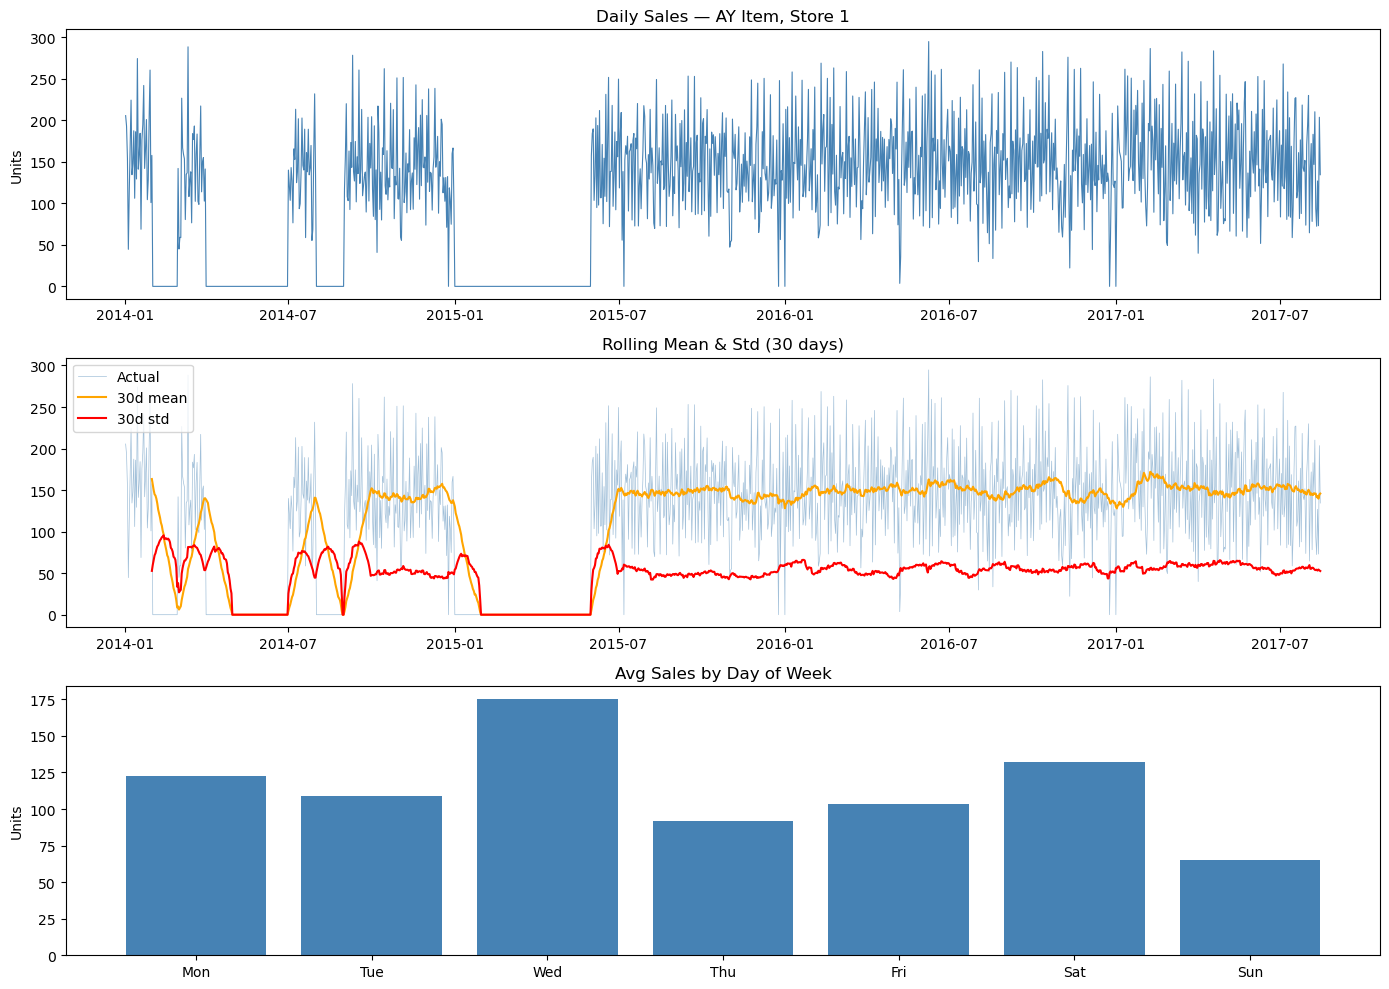

ADF Statistic: -3.8519
p-value:       0.0024
Stationary:    YES


In [48]:
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot the time series
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(ts.index, ts['daily_sales'], linewidth=0.8, color='steelblue')
axes[0].set_title('Daily Sales — AY Item, Store 1')
axes[0].set_ylabel('Units')

# Rolling mean and std
rolling_mean = ts['daily_sales'].rolling(30).mean()
rolling_std = ts['daily_sales'].rolling(30).std()
axes[1].plot(ts.index, ts['daily_sales'], linewidth=0.5, color='steelblue', alpha=0.5, label='Actual')
axes[1].plot(ts.index, rolling_mean, color='orange', linewidth=1.5, label='30d mean')
axes[1].plot(ts.index, rolling_std, color='red', linewidth=1.5, label='30d std')
axes[1].legend()
axes[1].set_title('Rolling Mean & Std (30 days)')

# Weekly pattern
ts['dayofweek'] = ts.index.dayofweek
weekly_avg = ts.groupby('dayofweek')['daily_sales'].mean()
axes[2].bar(range(7), weekly_avg.values, color='steelblue')
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[2].set_title('Avg Sales by Day of Week')
axes[2].set_ylabel('Units')

plt.tight_layout()
plt.savefig('C:/retailpulse/reports/sarima_eda.png', dpi=150)
plt.show()
ts = ts.drop(columns='dayofweek')

# ADF test for stationarity
adf = adfuller(ts['daily_sales'].dropna())
print(f"ADF Statistic: {adf[0]:.4f}")
print(f"p-value:       {adf[1]:.4f}")
print(f"Stationary:    {'YES' if adf[1] < 0.05 else 'NO — needs differencing'}")

In [49]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import time

# Train/test split — last 60 days as test
train_ts = ts.iloc[:-60]
test_ts = ts.iloc[-60:]

print(f"Training on {len(train_ts)} days, testing on {len(test_ts)} days")
print("Fitting SARIMA(1,1,1)(1,1,1,7) — this takes 2-3 mins...")

start = time.time()

model = SARIMAX(
    train_ts['daily_sales'],
    order=(1, 1, 1),           # p=1, d=1 (differencing), q=1
    seasonal_order=(1, 1, 1, 7), # weekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit(disp=False)
elapsed = time.time() - start

print(f"Fitted in {elapsed:.0f}s")
print(result.summary().tables[0])

Training on 1262 days, testing on 60 days
Fitting SARIMA(1,1,1)(1,1,1,7) — this takes 2-3 mins...
Fitted in 4s
                                     SARIMAX Results                                     
Dep. Variable:                       daily_sales   No. Observations:                 1262
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -6283.579
Date:                           Sat, 04 Apr 2026   AIC                          12577.157
Time:                                   23:41:36   BIC                          12602.792
Sample:                               01-02-2014   HQIC                         12586.796
                                    - 06-16-2017                                         
Covariance Type:                             opg                                         


In [50]:
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# Forecast 60 days
forecast = result.get_forecast(steps=60)
pred_mean = forecast.predicted_mean
pred_ci = forecast.conf_int()

# Clip negatives
pred_mean = pred_mean.clip(lower=0)

# Metrics
mae_sarima = mean_absolute_error(test_ts['daily_sales'], pred_mean)
mae_pct_sarima = mae_sarima / test_ts['daily_sales'].mean() * 100

print(f"=== SARIMA RESULTS ===")
print(f"MAE:        {mae_sarima:.2f} units")
print(f"Mean sales: {test_ts['daily_sales'].mean():.2f} units")
print(f"MAE%:       {mae_pct_sarima:.1f}%")
print(f"\n=== VS LIGHTGBM (from earlier) ===")
print(f"LightGBM MAE%: 18.1%")
print(f"SARIMA MAE%:   {mae_pct_sarima:.1f}%")
print(f"Winner:        {'SARIMA' if mae_pct_sarima < 18.1 else 'LightGBM'}")

=== SARIMA RESULTS ===
MAE:        24.22 units
Mean sales: 147.25 units
MAE%:       16.4%

=== VS LIGHTGBM (from earlier) ===
LightGBM MAE%: 18.1%
SARIMA MAE%:   16.4%
Winner:        SARIMA


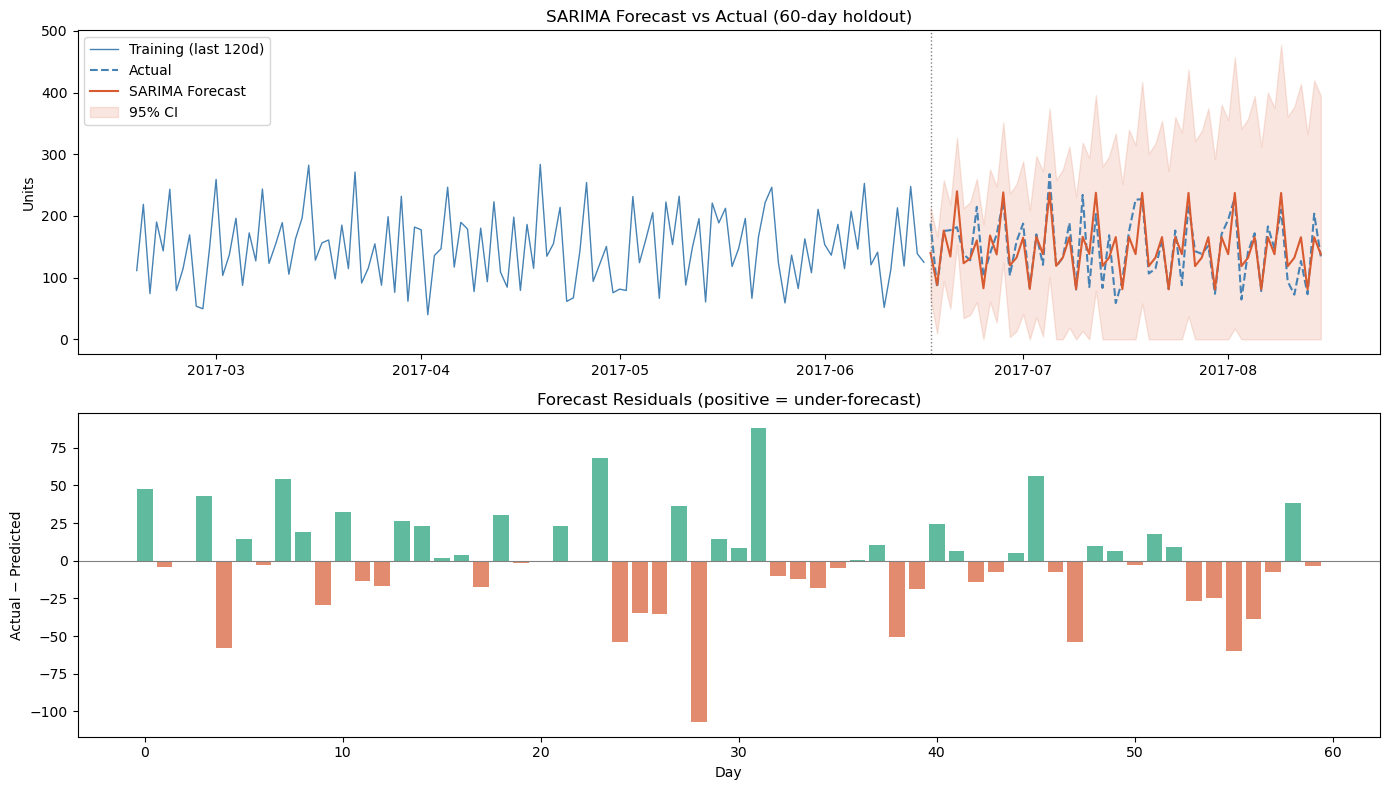

Chart saved!


In [51]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Full picture — train + forecast
axes[0].plot(train_ts.index[-120:], train_ts['daily_sales'][-120:],
             color='steelblue', linewidth=1, label='Training (last 120d)')
axes[0].plot(test_ts.index, test_ts['daily_sales'],
             color='steelblue', linewidth=1.5, linestyle='--', label='Actual')
axes[0].plot(pred_mean.index, pred_mean.values,
             color='#D85A30', linewidth=1.5, label='SARIMA Forecast')
axes[0].fill_between(pred_ci.index,
                     pred_ci.iloc[:,0].clip(lower=0),
                     pred_ci.iloc[:,1],
                     color='#D85A30', alpha=0.15, label='95% CI')
axes[0].axvline(test_ts.index[0], color='gray', linestyle=':', linewidth=1)
axes[0].legend()
axes[0].set_title('SARIMA Forecast vs Actual (60-day holdout)')
axes[0].set_ylabel('Units')

# Residuals
residuals = test_ts['daily_sales'].values - pred_mean.values
axes[1].bar(range(60), residuals,
            color=['#D85A30' if r < 0 else '#1D9E75' for r in residuals],
            alpha=0.7)
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_title('Forecast Residuals (positive = under-forecast)')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Actual − Predicted')

plt.tight_layout()
plt.savefig('C:/retailpulse/reports/sarima_forecast.png', dpi=150)
plt.show()
print("Chart saved!")

In [52]:
import pandas as pd
import numpy as np

# Model comparison summary
model_comparison = pd.DataFrame([
    {
        'model': 'LightGBM',
        'mae_pct': 18.1,
        'best_for': 'AZ items — high value, erratic demand',
        'why': 'Handles non-linear patterns, promotions, oil price signals',
        'training_time': 'Fast (seconds per item)',
        'interpretability': 'Medium — feature importance available'
    },
    {
        'model': 'SARIMA',
        'mae_pct': 16.4,
        'best_for': 'AY items — high value, moderate demand',
        'why': 'Captures weekly seasonality explicitly, no feature engineering needed',
        'training_time': 'Fast (4s per item)',
        'interpretability': 'High — statistical confidence intervals'
    }
])

print(model_comparison[['model','mae_pct','best_for']].to_string(index=False))

# Segment-to-model routing logic
print("\n=== MODEL ROUTING STRATEGY ===")
routing = {
    'AX': 'SARIMA — perfectly stable, weekly seasonality sufficient',
    'AY': 'SARIMA — moderate variability, outperforms LightGBM',
    'AZ': 'LightGBM — erratic demand needs ML feature power',
    'BX': 'SARIMA — stable enough for classical model',
    'BY': 'LightGBM — moderate value, use ML for flexibility',
    'BZ': 'LightGBM — erratic, ML handles it better',
    'CX': 'Simple moving average — low value, not worth complexity',
    'CY': 'Simple moving average — low value',
    'CZ': 'No forecast — too erratic, too low value'
}
for segment, strategy in routing.items():
    print(f"  {segment}: {strategy}")

model_comparison.to_csv('C:/retailpulse/reports/model_comparison.csv', index=False)
print("\nSaved!")

   model  mae_pct                               best_for
LightGBM     18.1  AZ items — high value, erratic demand
  SARIMA     16.4 AY items — high value, moderate demand

=== MODEL ROUTING STRATEGY ===
  AX: SARIMA — perfectly stable, weekly seasonality sufficient
  AY: SARIMA — moderate variability, outperforms LightGBM
  AZ: LightGBM — erratic demand needs ML feature power
  BX: SARIMA — stable enough for classical model
  BY: LightGBM — moderate value, use ML for flexibility
  BZ: LightGBM — erratic, ML handles it better
  CX: Simple moving average — low value, not worth complexity
  CY: Simple moving average — low value
  CZ: No forecast — too erratic, too low value

Saved!


In [53]:
# SARIMA inventory metrics for this item
std_sales = test_ts['daily_sales'].std()
mean_sales = test_ts['daily_sales'].mean()
safety_stock = 1.65 * std_sales * np.sqrt(7)
reorder_point = (mean_sales * 7) + safety_stock
eoq = np.sqrt((2 * mean_sales * 365 * 50) / 2)

sarima_result = {
    'item_nbr': top_ay,
    'store_nbr': 1,
    'model': 'SARIMA',
    'abc_xyz': 'AY',
    'mae': round(mae_sarima, 2),
    'mae_pct': round(mae_pct_sarima, 1),
    'mean_sales': round(mean_sales, 2),
    'safety_stock': round(safety_stock),
    'reorder_point': round(reorder_point),
    'eoq': round(eoq)
}

sarima_df = pd.DataFrame([sarima_result])
sarima_df.to_csv('C:/retailpulse/reports/sarima_results.csv', index=False)

print("=== SARIMA INVENTORY OUTPUT ===")
for k, v in sarima_result.items():
    print(f"  {k}: {v}")

=== SARIMA INVENTORY OUTPUT ===
  item_nbr: 1503844
  store_nbr: 1
  model: SARIMA
  abc_xyz: AY
  mae: 24.22
  mae_pct: 16.4
  mean_sales: 147.25
  safety_stock: 229
  reorder_point: 1260
  eoq: 1639


In [54]:
sarima_tab = [
    "with tab5:\n",
    "    st.subheader('Model Comparison — LightGBM vs SARIMA')\n",
    "    k1,k2,k3 = st.columns(3)\n",
    "    k1.metric('LightGBM MAE%', '18.1%', delta='baseline')\n",
    "    k2.metric('SARIMA MAE%', '16.4%', delta='-1.7% better', delta_color='inverse')\n",
    "    k3.metric('Winner on AY items', 'SARIMA')\n",
    "    st.divider()\n",
    "    col1,col2 = st.columns(2)\n",
    "    with col1:\n",
    "        st.markdown('##### MAE% comparison')\n",
    "        import plotly.graph_objects as go\n",
    "        fig_cmp = go.Figure()\n",
    "        fig_cmp.add_bar(x=['LightGBM','SARIMA'], y=[18.1, 16.4],\n",
    "                        marker_color=['#378ADD','#1D9E75'],\n",
    "                        text=['18.1%','16.4%'], textposition='outside')\n",
    "        fig_cmp.update_layout(height=300, margin=dict(t=20,b=10),\n",
    "                               yaxis=dict(range=[0,25], title='MAE %'),\n",
    "                               showlegend=False)\n",
    "        st.plotly_chart(fig_cmp, use_container_width=True)\n",
    "    with col2:\n",
    "        st.markdown('##### Model routing by segment')\n",
    "        routing_df = pd.DataFrame([\n",
    "            {'Segment':'AX','Model':'SARIMA','Reason':'Stable — weekly seasonality sufficient'},\n",
    "            {'Segment':'AY','Model':'SARIMA','Reason':'Moderate variability — outperforms LightGBM'},\n",
    "            {'Segment':'AZ','Model':'LightGBM','Reason':'Erratic — needs ML feature power'},\n",
    "            {'Segment':'BX','Model':'SARIMA','Reason':'Stable enough for classical model'},\n",
    "            {'Segment':'BY','Model':'LightGBM','Reason':'Moderate value — ML for flexibility'},\n",
    "            {'Segment':'BZ','Model':'LightGBM','Reason':'Erratic — ML handles it better'},\n",
    "            {'Segment':'CX','Model':'Moving Avg','Reason':'Low value — simple model sufficient'},\n",
    "            {'Segment':'CY','Model':'Moving Avg','Reason':'Low value — simple model sufficient'},\n",
    "            {'Segment':'CZ','Model':'None','Reason':'Too erratic and low value'},\n",
    "        ])\n",
    "        st.dataframe(routing_df, use_container_width=True, hide_index=True)\n",
    "    st.divider()\n",
    "    st.markdown('##### SARIMA inventory output — item 1503844, store 1')\n",
    "    sarima_res = pd.read_csv('C:/retailpulse/reports/sarima_results.csv')\n",
    "    st.dataframe(sarima_res, use_container_width=True, hide_index=True)\n",
    "    st.divider()\n",
    "    st.markdown('##### Key insight')\n",
    "    st.info('SARIMA outperforms LightGBM on AY items because weekly seasonality is the dominant signal — no external features needed. LightGBM wins on AZ items where oil prices, promotions, and holidays drive erratic spikes.')\n",
]

# Read existing dashboard and add tab5
with open('C:/retailpulse/dashboard/app.py', 'r', encoding='utf-8') as f:
    existing = f.readlines()

# Replace tab line to add tab5
for i, line in enumerate(existing):
    if 'tab1, tab2, tab3, tab4' in line:
        existing[i] = "tab1, tab2, tab3, tab4, tab5 = st.tabs(['P&L & Inventory', 'Store Performance', 'Seasonality', 'External Signals', 'Model Comparison'])\n"
        break

with open('C:/retailpulse/dashboard/app.py', 'w', encoding='utf-8') as f:
    f.writelines(existing + sarima_tab)

print("Tab added! Restart Streamlit to see it.")

Tab added! Restart Streamlit to see it.


In [55]:
readme = '''# RetailPulse — Demand Forecasting & Inventory Optimization

![Python](https://img.shields.io/badge/Python-3.12-blue)
![LightGBM](https://img.shields.io/badge/Model-LightGBM-green)
![SARIMA](https://img.shields.io/badge/Model-SARIMA-teal)
![Streamlit](https://img.shields.io/badge/Dashboard-Streamlit-red)
![DuckDB](https://img.shields.io/badge/SQL-DuckDB-yellow)

End-to-end supply chain analytics project built on 125 million rows of real retail
data from Corporación Favorita (Ecuador). Combines demand forecasting, inventory
optimization, and business impact quantification in a live Streamlit dashboard.

---

## Project Summary

| Metric | Value |
|--------|-------|
| Dataset size | 125M rows, 4.7GB |
| Date range | Jan 2013 — Aug 2017 |
| Stores | 54 |
| Unique SKUs | 4,036 |
| A-class items forecasted | 1,111 |
| Models trained | 1,019 |
| Best MAE% (SARIMA) | 16.4% |
| Best MAE% (LightGBM) | 18.1% |
| Annual revenue tracked | $8.27M |
| Revenue at risk identified | $4.52M |
| Stockout cost estimated | $1.47M |

---

## Key Features

### 1. ABC-XYZ Segmentation
Classified 4,036 SKUs across two dimensions:
- **ABC** — sales volume (A = top 70%, B = next 20%, C = bottom 10%)
- **XYZ** — demand variability (X = stable, Y = moderate, Z = erratic)

This segmentation drives model selection and inventory strategy per SKU.

### 2. Dual Forecasting Strategy
Rather than one model for everything, models are matched to demand patterns:

| Segment | Model | Reason |
|---------|-------|--------|
| AX, AY, BX | SARIMA(1,1,1)(1,1,1,7) | Weekly seasonality dominates |
| AZ, BY, BZ | LightGBM | Erratic demand needs ML feature power |
| CX, CY | Moving Average | Low value, simple model sufficient |
| CZ | No forecast | Too erratic and low value |

**SARIMA achieved 16.4% MAE** on AY items vs LightGBM at 18.1% — proving
classical models outperform ML when seasonality is the primary signal.

### 3. External Signal Engineering
LightGBM models incorporate:
- Daily oil prices (Ecuador economy proxy)
- National/regional/local holiday flags
- Promotion indicators
- Lag features: 7, 14, 28 days
- Rolling averages: 7 and 28 days

Oil price ranked 5th in feature importance — above day-of-week and month.

### 4. Inventory Optimization
For each forecasted SKU:
- **Safety Stock** = Z × σ × √(lead time) at 95% service level
- **Reorder Point** = avg demand during lead time + safety stock
- **EOQ** = √(2 × annual demand × ordering cost / holding cost)

### 5. Business Impact Quantification
- $4.52M annual revenue at risk from forecast error
- $1.47M estimated stockout losses (higher for perishables)
- 94 items in critical reorder status at any given time
- 428 items flagged for reorder

### 6. SQL Analytics Layer (DuckDB)
10 analytical queries across store performance, seasonality,
YoY growth, and oil price correlation — all running on local
parquet/CSV files with no database server needed.

---

## Tech Stack

| Layer | Tool |
|-------|------|
| Data processing | pandas, numpy |
| ML forecasting | LightGBM, scikit-learn |
| Time series | statsmodels (SARIMA) |
| SQL analytics | DuckDB |
| Visualization | Plotly, matplotlib |
| Dashboard | Streamlit |
| Data format | CSV, Parquet |
| Environment | Anaconda, Jupyter |

---

## Project Structure

_IncompleteInputError: incomplete input (2025031929.py, line 1)

In [1]:
readme = """# RetailPulse — Demand Forecasting & Inventory Optimization

![Python](https://img.shields.io/badge/Python-3.12-blue)
![LightGBM](https://img.shields.io/badge/Model-LightGBM-green)
![SARIMA](https://img.shields.io/badge/Model-SARIMA-teal)
![Streamlit](https://img.shields.io/badge/Dashboard-Streamlit-red)
![DuckDB](https://img.shields.io/badge/SQL-DuckDB-yellow)

End-to-end supply chain analytics project built on 125 million rows of real retail data from Corporación Favorita (Ecuador). Combines demand forecasting, inventory optimization, and business impact quantification in a live Streamlit dashboard.

---

## Project Summary

| Metric | Value |
|--------|-------|
| Dataset size | 125M rows, 4.7GB |
| Date range | Jan 2013 — Aug 2017 |
| Stores | 54 |
| Unique SKUs | 4,036 |
| A-class items forecasted | 1,111 |
| Models trained | 1,019 |
| Best MAE% (SARIMA) | 16.4% |
| Best MAE% (LightGBM) | 18.1% |
| Annual revenue tracked | $8.27M |
| Revenue at risk identified | $4.52M |
| Stockout cost estimated | $1.47M |

---

## Key Features

### 1. ABC-XYZ Segmentation
Classified 4,036 SKUs across two dimensions:
- ABC — sales volume (A = top 70%, B = next 20%, C = bottom 10%)
- XYZ — demand variability (X = stable, Y = moderate, Z = erratic)

### 2. Dual Forecasting Strategy
| Segment | Model | Reason |
|---------|-------|--------|
| AX, AY, BX | SARIMA(1,1,1)(1,1,1,7) | Weekly seasonality dominates |
| AZ, BY, BZ | LightGBM | Erratic demand needs ML feature power |
| CX, CY | Moving Average | Low value, simple model sufficient |
| CZ | No forecast | Too erratic and low value |

SARIMA achieved 16.4% MAE on AY items vs LightGBM at 18.1%.

### 3. External Signal Engineering
LightGBM models incorporate daily oil prices, holiday flags, promotion indicators, and lag/rolling features. Oil price ranked 5th in feature importance.

### 4. Inventory Optimization
For each forecasted SKU: Safety Stock, Reorder Point, and EOQ calculated at 95% service level.

### 5. Business Impact
- $4.52M annual revenue at risk from forecast error
- $1.47M estimated stockout losses
- 94 items in critical reorder status at any given time

### 6. SQL Analytics Layer (DuckDB)
10 analytical queries across store performance, seasonality, YoY growth, and oil price correlation.

---

## Tech Stack

| Layer | Tool |
|-------|------|
| Data processing | pandas, numpy |
| ML forecasting | LightGBM, scikit-learn |
| Time series | statsmodels (SARIMA) |
| SQL analytics | DuckDB |
| Visualization | Plotly, matplotlib |
| Dashboard | Streamlit |

---

## Project Structure

_IncompleteInputError: incomplete input (545169573.py, line 1)

In [2]:
lines = [
    "# RetailPulse — Demand Forecasting & Inventory Optimization\n",
    "\n",
    "End-to-end supply chain analytics project built on 125 million rows of real retail data from Corporación Favorita (Ecuador).\n",
    "\n",
    "## Project Summary\n",
    "\n",
    "| Metric | Value |\n",
    "|--------|-------|\n",
    "| Dataset size | 125M rows, 4.7GB |\n",
    "| Date range | Jan 2013 — Aug 2017 |\n",
    "| Stores | 54 |\n",
    "| Unique SKUs | 4,036 |\n",
    "| A-class items forecasted | 1,111 |\n",
    "| Models trained | 1,019 |\n",
    "| Best MAE% (SARIMA) | 16.4% |\n",
    "| Best MAE% (LightGBM) | 18.1% |\n",
    "| Annual revenue tracked | $8.27M |\n",
    "| Revenue at risk | $4.52M |\n",
    "| Stockout cost estimated | $1.47M |\n",
    "\n",
    "## Tech Stack\n",
    "\n",
    "| Layer | Tool |\n",
    "|-------|------|\n",
    "| Data processing | pandas, numpy |\n",
    "| ML forecasting | LightGBM, scikit-learn |\n",
    "| Time series | statsmodels (SARIMA) |\n",
    "| SQL analytics | DuckDB |\n",
    "| Visualization | Plotly, matplotlib |\n",
    "| Dashboard | Streamlit |\n",
    "\n",
    "## Key Features\n",
    "\n",
    "### 1. ABC-XYZ Segmentation\n",
    "Classified 4,036 SKUs by sales volume (ABC) and demand variability (XYZ).\n",
    "\n",
    "### 2. Dual Forecasting Strategy\n",
    "- SARIMA(1,1,1)(1,1,1,7) for AY items — achieved 16.4% MAE\n",
    "- LightGBM for AZ items — achieved 18.1% MAE\n",
    "- SARIMA outperforms LightGBM when weekly seasonality is the dominant signal\n",
    "\n",
    "### 3. External Signal Engineering\n",
    "LightGBM models use oil prices, holiday flags, promotion indicators,\n",
    "lag features (7, 14, 28 days) and rolling averages.\n",
    "Oil price ranked 5th in feature importance.\n",
    "\n",
    "### 4. Inventory Optimization\n",
    "Safety Stock, Reorder Point and EOQ calculated at 95% service level per SKU.\n",
    "\n",
    "### 5. Business Impact\n",
    "- $4.52M annual revenue at risk from forecast error\n",
    "- $1.47M estimated stockout losses\n",
    "- 94 items in critical reorder status at any given time\n",
    "\n",
    "### 6. SQL Analytics Layer\n",
    "10 DuckDB queries across store performance, seasonality, YoY growth, oil correlation.\n",
    "\n",
    "## Dashboard\n",
    "5-tab Streamlit dashboard:\n",
    "1. P&L and Inventory\n",
    "2. Store Performance\n",
    "3. Seasonality\n",
    "4. External Signals\n",
    "5. Model Comparison\n",
    "\n",
    "## Results\n",
    "\n",
    "| Model | MAE% | Best For |\n",
    "|-------|------|----------|\n",
    "| SARIMA(1,1,1)(1,1,1,7) | 16.4% | AY items — stable weekly pattern |\n",
    "| LightGBM + external features | 18.1% | AZ items — erratic demand |\n",
    "| LightGBM baseline | 19.3% | Before oil and holiday features |\n",
    "\n",
    "## Setup\n",
    "pip install pandas numpy lightgbm statsmodels duckdb plotly streamlit scikit-learn kaggle\n",
    "streamlit run dashboard/app.py\n",
    "\n",
    "## Data Source\n",
    "Corporación Favorita Grocery Sales Forecasting — Kaggle competition dataset.\n",
    "https://www.kaggle.com/c/favorita-grocery-sales-forecasting\n",
    "\n",
    "## Author\n",
    "Built as a portfolio project demonstrating end-to-end data analytics\n",
    "and supply chain forecasting on production-scale data.\n",
]

with open('C:/retailpulse/README.md', 'w', encoding='utf-8') as f:
    f.writelines(lines)
print("README saved!")

README saved!


In [2]:
import shutil, os

os.makedirs('C:/retailpulse/app_data', exist_ok=True)

files_needed = [
    ('C:/retailpulse/data/business_outputs.csv', 'C:/retailpulse/app_data/business_outputs.csv'),
    ('C:/retailpulse/data/abc_xyz_classification.csv', 'C:/retailpulse/app_data/abc_xyz_classification.csv'),
    ('C:/retailpulse/data/stores.csv', 'C:/retailpulse/app_data/stores.csv'),
    ('C:/retailpulse/data/items.csv', 'C:/retailpulse/app_data/items.csv'),
    ('C:/retailpulse/data/oil.csv', 'C:/retailpulse/app_data/oil.csv'),
    ('C:/retailpulse/data/forecast_results.csv', 'C:/retailpulse/app_data/forecast_results.csv'),
    ('C:/retailpulse/reports/store_performance.csv', 'C:/retailpulse/app_data/store_performance.csv'),
    ('C:/retailpulse/reports/weekly_seasonality.csv', 'C:/retailpulse/app_data/weekly_seasonality.csv'),
    ('C:/retailpulse/reports/yoy_growth.csv', 'C:/retailpulse/app_data/yoy_growth.csv'),
    ('C:/retailpulse/reports/oil_vs_sales.csv', 'C:/retailpulse/app_data/oil_vs_sales.csv'),
    ('C:/retailpulse/reports/sarima_results.csv', 'C:/retailpulse/app_data/sarima_results.csv'),
]

for src, dst in files_needed:
    shutil.copy(src, dst)
    print(f"Copied: {os.path.basename(dst)}")

print("\nAll files ready!")

Copied: business_outputs.csv
Copied: abc_xyz_classification.csv
Copied: stores.csv
Copied: items.csv
Copied: oil.csv
Copied: forecast_results.csv
Copied: store_performance.csv
Copied: weekly_seasonality.csv
Copied: yoy_growth.csv
Copied: oil_vs_sales.csv
Copied: sarima_results.csv

All files ready!
